# 🚀Problem Statement

Scaler is an online tech-versity offering intensive computer science & Data Science courses through live classes delivered by tech leaders and subject matter experts. The meticulously structured program enhances the skills of software professionals by offering a modern curriculum with exposure to the latest technologies. It is a product by InterviewBit.

As a data scientist, responsible to work with the analytics vertical of Scaler, focused on profiling the best companies and job positions to work for from the Scaler database. You are provided with the information for a segment of learners and tasked to cluster them on the basis of their job profile, company, and other features. Ideally, these clusters should have similar characteristics.

# 🎯 Objective:

Develop a data-driven approach using clustering techniques to profile Scaler learners based on their professional backgrounds, compensation, and job roles. This profiling will enable personalized learning experiences and tailored mentorship.



#  🧠 Key Reasons the Learner Profile Is Critical

1. Personalized Learning Experience
Their background, goals, learning pace, skill gaps help the system personalize:
*   Difficulty levels
*   Course recommendations
*   Project assignments
*   Feedback and nudges

2. Targeted Marketing & Sales
*   Profiles help the company segment learners:
    - Working professionals vs. college students
    - Domain switchers vs. skill enhancers
    - High-conversion vs. passive users

3. Improved Retention and Engagement
*   Tracking profile traits helps flag drop-off risks or frustration.
*   You can send:
    - Smart reminders
    - Peer motivation prompts
    - Content refreshes or career nudges

4. Better Career Outcomes
*   If the profile includes work history, career goals, and performance, the system can:
*   Match learners to jobs
*   Show proof of progress (certificates, GitHub)
*   Enable mentor matchmaking

5. Data-Driven Product Improvement
*   Learner profiles power:
    - A/B tests for different learner types
    - Feature prioritization (e.g., resume builder vs. mock interviews)
    - Funnel analysis: where different types of learners drop off

**Data Dictionary:**

**Unnamed 0** - Index of the dataset

**Email_hash** - Anonymised Personal Identifiable Information (PII)

**Company_hash** - This represents an anonymized identifier for the company, which is the current employer of the learner.

**orgyear** - Employment start date

**CTC** - Current CTC

**Job_position** - Job profile in the company

**CTC_updated_year** - Year in which CTC got updated (Yearly increments, Promotions)

# Understanding the dataset

**Importing necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.cluster.hierarchy as sch
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_rows',1000)

**Importing dataset**

In [3]:
df = pd.read_csv('/content/scaler_clustering.csv')
df

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0
...,...,...,...,...,...,...,...
205838,206918,vuurt xzw,70027b728c8ee901fe979533ed94ffda97be08fc23f33b...,2008.0,220000,NaN,2019.0
205839,206919,husqvawgb,7f7292ffad724ebbe9ca860f515245368d714c84705b42...,2017.0,500000,NaN,2020.0
205840,206920,vwwgrxnt,cb25cc7304e9a24facda7f5567c7922ffc48e3d5d6018c...,2021.0,700000,NaN,2021.0
205841,206921,zgn vuurxwvmrt,fb46a1a2752f5f652ce634f6178d0578ef6995ee59f6c8...,2019.0,5100000,NaN,2019.0


In [4]:
df.shape

(205843, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205843 entries, 0 to 205842
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        205843 non-null  int64  
 1   company_hash      205799 non-null  object 
 2   email_hash        205843 non-null  object 
 3   orgyear           205757 non-null  float64
 4   ctc               205843 non-null  int64  
 5   job_position      153279 non-null  object 
 6   ctc_updated_year  205843 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.0+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,205843.0,1.032739e+05,5.974131e+04,0.0,51518.5,103151.0,154992.5,2.069220e+05
orgyear,205757.0,2.014883e+03,6.357112e+01,0.0,2013.0,2016.0,2018.0,2.016500e+04
ctc,205843.0,2.271685e+06,1.180091e+07,2.0,530000.0,950000.0,1700000.0,1.000150e+09
ctc_updated_year,205843.0,2.019628e+03,1.325104e+00,2015.0,2019.0,2020.0,2021.0,2.021000e+03


In [7]:
df.describe(exclude = ['float', 'int']).T

,count,unique,top,freq
company_hash,205799,37299,nvnv wgzohrnvzwj otqcxwto,8337
email_hash,205843,153443,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,10
job_position,153279,1016,Backend Engineer,43554


### **🔰 Summary Statistics**

* **Company Hash**:
  + Count: 205,799
  + Unique: 37,299
  + Top: nvnv wgzohrnvzwj otqcxwto
  + Frequency: 8,337
* **Email Hash**:
  + Count: 205,843
  + Unique: 153,443
  + Top: bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...
  + Frequency: 10
* **Job Position**:
  + Count: 153,279
  + Unique: 1,016
  + Top: Backend Engineer
  + Frequency: 43,554


In [8]:
df1 = df.copy()

In [9]:
df1.drop('Unnamed: 0', axis = 1, inplace = True)

1. company_hash could be potential feature in classifying the learners
2. orgyear, cte_updated_year should be converted to datetime format
3. Validity of years in orgyear and ctc_updated_year needs to be checked

**Unique values in each feature**

In [10]:
cat_cols = df1.select_dtypes(include='object').columns
cat_cols

Index(['company_hash', 'email_hash', 'job_position'], dtype='object')

In [11]:
for column in cat_cols:
    print(f"Column: {column}")
    print()
    print(f"Total Unique Values: {df1[column].nunique()}")
    print()
    print(df1[column].value_counts())
    print("-" * 80)
    print()

Column: company_hash

Total Unique Values: 37299

company_hash
nvnv wgzohrnvzwj otqcxwto    8337
xzegojo                      5381
vbvkgz                       3481
zgn vuurxwvmrt vwwghzn       3411
wgszxkvzn                    3240
                             ... 
pzhastbt tdqhzzq                1
ltbontu mj xzctowg              1
tkwqta ucn rna                  1
zhwrtvq ogenfvqt                1
bmq nvqstnxzs                   1
Name: count, Length: 37299, dtype: int64
--------------------------------------------------------------------------------

Column: email_hash

Total Unique Values: 153443

email_hash
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b    10
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378     9
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee     9
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c     9
d598d6f1fb21b45593c2afc1c2f76ae9f4cb7167156cdf93246d4192a89d8065     8
                         

1. Distinct company's - 37300
2. Distinct emails - 153443
3. Repeated emails - 52400 emails have been repeated.
This could be because of the learners moving from one company to other or the learner associated with a company for multiple number of times.
4. Distinct job positions - 1016

In [12]:
numeric_cols = df1.select_dtypes(include='number').columns
numeric_cols

Index(['orgyear', 'ctc', 'ctc_updated_year'], dtype='object')

In [13]:
for column in numeric_cols:
    print(f"Column: {column}")
    print()
    print(f"Total Unique Values: {df1[column].nunique()}")
    print()
    print(df1[column].value_counts())
    print("-" * 80)
    print()

Column: orgyear

Total Unique Values: 77

orgyear
2018.0     25256
2019.0     23427
2017.0     23239
2016.0     23043
2015.0     20610
2014.0     16696
2020.0     13431
2013.0     12351
2012.0     10493
2011.0      7970
2010.0      5751
2009.0      3777
2021.0      3670
2008.0      2728
2007.0      2257
2006.0      2075
2005.0      1873
2004.0      1455
2003.0      1018
2022.0       911
2001.0       713
2002.0       685
2000.0       495
1999.0       340
1998.0       279
2023.0       252
1997.0       234
1996.0       134
1995.0        94
1991.0        79
1993.0        74
1994.0        65
1992.0        47
2024.0        43
1990.0        38
1989.0        22
0.0           17
2025.0        13
1988.0        10
2026.0         9
1986.0         8
1987.0         6
3.0            6
1985.0         5
2031.0         5
2029.0         5
1982.0         4
2028.0         4
2.0            3
1984.0         3
91.0           3
1970.0         2
1.0            2
5.0            2
6.0            2
20165.0        

# **Data Preprocessing**

*   Data Cleaning
*   Dropping duplicates
*   Dropping Irrelevant columns
*   Checking Null Values and Treatment using KNN imputation for Numerical attributes
*   Treating Outliers
*   Transform and encode
*   Normalize numerical fields

**Cleaning the data**

In [14]:
# mystring='\tAirtel X Labs'
# re.sub('[^A-Za-z0-9 ]+', '', mystring)

In [15]:
# Function to clean special characters
def clean_string(s):
  new_string=re.sub('[^A-Za-z ]+', '', s)
  return new_string
    # if not isinstance(s, str):
    #     s = str(s)
    # return re.sub('[^A-Za-z0-9 ]+', '', s)

**company_hash column**

In [16]:
import re

In [17]:
# Apply the function to the 'company_hash' column
df1['company_hash'] = df1['company_hash'].apply(lambda x: clean_string(str(x)))
df1['company_hash']  = df1['company_hash'].apply(lambda x:x.lower())
df1['company_hash'] = df1['company_hash'].apply(lambda x:x.strip())

**job_position column**

In [18]:
df1['job_position'] = df1['job_position'].apply(lambda x: clean_string(str(x)))
df1['job_position'] = df1['job_position'].apply(lambda x: x.lower())
df1['job_position'] = df1['job_position'].apply(lambda x: x.strip())

**converting ctc_updated_year and orgyear to datetime format**

**ctc_updated_column**

In [19]:
df1['ctc_updated_year'] = pd.to_datetime(df1['ctc_updated_year'], format = '%Y')
df1['ctc_updated_year'] = df1['ctc_updated_year'].dt.year

**orgyear column**

In [20]:
valid_years = range(1900, 2025)
# convert orgyear to valid year
df1['orgyear'] = df1['orgyear'].apply(lambda x: x if x in valid_years else np.nan)
# drop the invalid date columns filled with nan values, convert the rest
# of the columns to int data type and then to datetime format
df1['orgyear'] = pd.to_datetime(df1['orgyear'].dropna().astype(int), format = '%Y')
# extract just year from the datetime
df1['orgyear'] = df1['orgyear'].dt.year
# convert orgyear to nullable pandas nullable integer type( Int64) that contains both int values and NaN values
df1['orgyear'] = df1['orgyear'].astype('Int64')

In [21]:
df1.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016,1100000,other,2020
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018,449999,fullstack engineer,2019
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015,2000000,backend engineer,2020
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017,700000,backend engineer,2019
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017,1400000,fullstack engineer,2019


In [22]:
# df1.drop(columns = ['email_hash'], inplace = True)

**Duplicate Values**

In [23]:
df1.duplicated().sum()

np.int64(146)

In [24]:
df1.drop_duplicates(inplace = True)
df1.shape

(205697, 6)

In [25]:
# email_duplicates = df1[df1.duplicated(subset = ['email_hash'], keep = False)]
# email_duplicates

In [ ]:
distinct_company = df1['company_hash'].unique()
# set(distinct_company)

In [27]:
job_counts = df1['job_position'].unique()
set(job_counts)

{'',
 'a group chat application',
 'abap developer',
 'account',
 'administrative clerk',
 'administrator',
 'advisor',
 'advisory consultant  uiux expert',
 'advisory software engineer',
 'advisory system analyat',
 'agency collection manager',
 'ai engineer',
 'air force',
 'analyst  software engineer',
 'analyst consultant',
 'analyst programmer',
 'analytics and insite devloper',
 'android application developer',
 'android developer sr executive',
 'android engineer',
 'android facilitator',
 'android lead',
 'any technical',
 'app developer',
 'application developer',
 'application developer analyst',
 'application developer frontend',
 'application development',
 'application development analyst',
 'application development associate',
 'application development senior analyst',
 'application development team lead',
 'application developmentaassociate',
 'application engineer',
 'application engineer ii',
 'applications engineer',
 'applied scientist',
 'applied scientist ii',
 'ar

**There are empty values in both job_hash and email_hash columns**

In [28]:
df1[(df1['company_hash'] == '')].shape[0]

86

In [29]:
df1[(df1['job_position'] == '')].shape[0]

9

In [30]:
df1[((df1['company_hash'] == '') | (df1['job_position'] == ''))].shape

(95, 6)

**Removing rows that are empty in either of the rows job_position or company_hash**

In [31]:
df1 = df1[~((df1['company_hash'] == '') | (df1['job_position'] == ''))]
df1.shape

(205602, 6)

In [32]:
# df1 = df1.drop_duplicates(subset = ['email_hash'], keep = 'last')
# df1

**Null Values**

In [33]:
df1.isna().sum()

,0
company_hash,0
email_hash,0
orgyear,172
ctc,0
job_position,0
ctc_updated_year,0


**Imputing orgyear with median values based on company_hash**

In [34]:
company_median_orgyear = df1.groupby('company_hash')['orgyear'].median()
company_median_orgyear

,orgyear
company_hash,
a,2017.0
a b onttr wgqu,2019.0
a j uvnxr owyggr ge tzsxzttqxzs vwvatbj vbmx,2015.0
a ntwy ogrhnxgzo ucn rna,2013.0
a ntwyzgrgsxto,2015.0
...,...
zz,2011.0
zz wgzztwn mya,2009.0
zzb ztdnstz vacxogqj ucn rna,2017.0


**fill missing (NaN) values in the orgyear column with values from a different source (company_median_org_year), depending on the company_hash. If orgyear is not missing, it leaves it as it is.**

In [35]:
def null_imputation(table, main_col, null_col):
    if pd.isnull(null_col):
        return table[main_col]
    else:
        return null_col
df1['orgyear']=df1.apply(lambda x: null_imputation(company_median_orgyear,x['company_hash'],x['orgyear'] ), axis=1)

**KNN imputation can be used too but as the data is an year column i preferred to use median imputation to favour the usage of the column for further analysis**

In [36]:
# # Impute missing values in numerical columns using KNN
# knn_imputer = KNNImputer(n_neighbors=3)

# # Select only numerical columns for KNN imputation
# numerical_cols = ['orgyear']

# # Fit and transform the KNN imputer on the numerical columns
# df1.loc[:, numerical_cols] = knn_imputer.fit_transform(df1[numerical_cols])

In [37]:
df1['orgyear']

,orgyear
0,2016
1,2018
2,2015
3,2017
4,2017
...,...
205838,2008
205839,2017
205840,2021
205841,2019


In [38]:
len(df1[df1['orgyear'].isnull()])

54

In [39]:
df1=df1[~df1['orgyear'].isnull()]
df1.isna().sum()

,0
company_hash,0
email_hash,0
orgyear,0
ctc,0
job_position,0
ctc_updated_year,0


**Treating Outliers**

**Extreme Values in numerical values**

<Axes: xlabel='ctc_updated_year'>

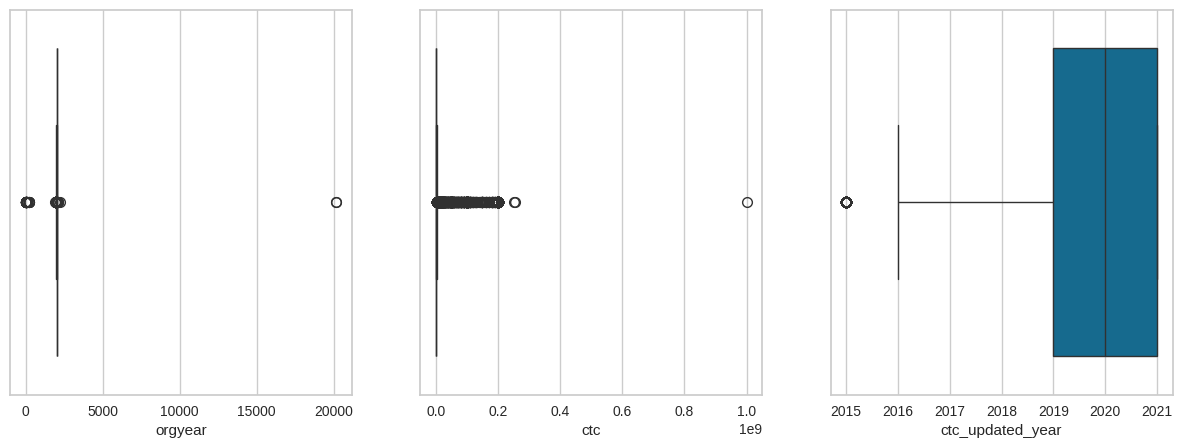

In [40]:
# ['Unnamed: 0', 'orgyear', 'ctc', 'ctc_updated_year']
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(x = df['orgyear'])
plt.subplot(1,3,2)
sns.boxplot(x = df['ctc'])
plt.subplot(1,3,3)
sns.boxplot(x = df['ctc_updated_year'])

Text(0.5, 1.0, 'Distribution of orgyear')

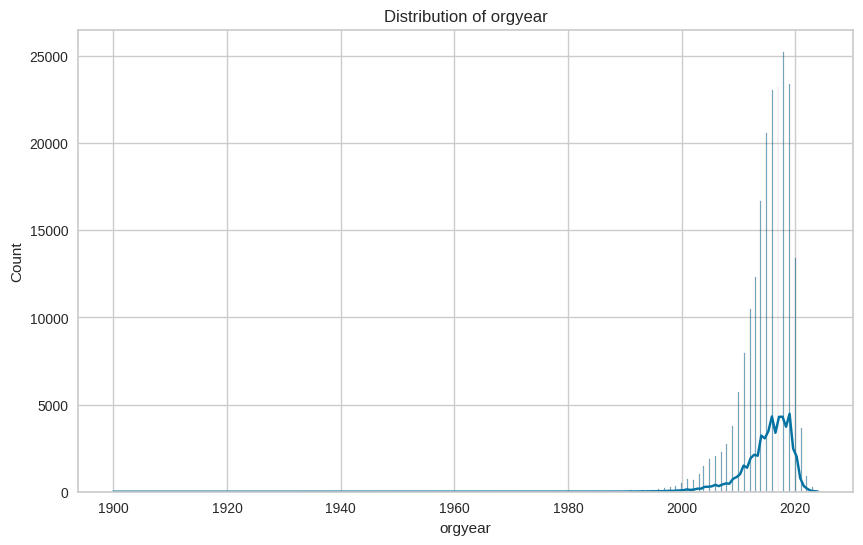

In [41]:
plt.figure(figsize=(10,6))
sns.histplot(df1['orgyear'], kde=True)  # kde=True adds smooth curve
plt.title('Distribution of orgyear')

**IQR method**

**orgyear**

In [42]:
q1 = df1['orgyear'].quantile(0.25)
q3 = df1['orgyear'].quantile(0.75)
iqr = q3 - q1
orgyear_lower_bound = q1 - 1.5 * iqr
orgyear_upper_bound = q3 + 1.5 * iqr
df1 = df1[(df1['orgyear'] >= orgyear_lower_bound) & (df1['orgyear'] <= orgyear_upper_bound)]

In [43]:
orgyear_outliers = df1[(df1['orgyear'] < orgyear_lower_bound) | (df1['orgyear'] > orgyear_upper_bound)]
orgyear_outliers

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year


**ctc**

In [44]:
df1['ctc']

,ctc
0,1100000
1,449999
2,2000000
3,700000
4,1400000
...,...
205838,220000
205839,500000
205840,700000
205841,5100000


Text(0.5, 1.0, 'Distribution of ctc')

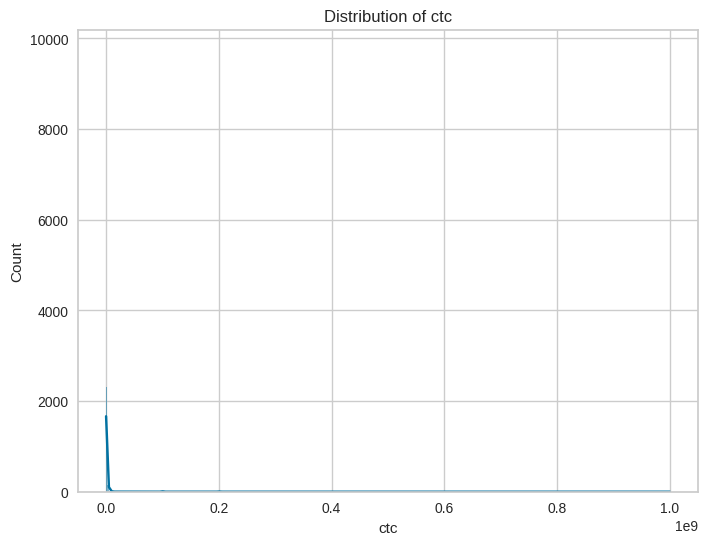

In [45]:
plt.figure(figsize=(8,6))
sns.histplot(df1['ctc'], kde=True)  # kde=True adds smooth curve
plt.title('Distribution of ctc')

**Presence of Outliers:**

The histogram suggests there are very large outlier values in the ctc column.

These outliers are distorting the plot and possibly impacting any modeling, clustering, or statistics you do later.

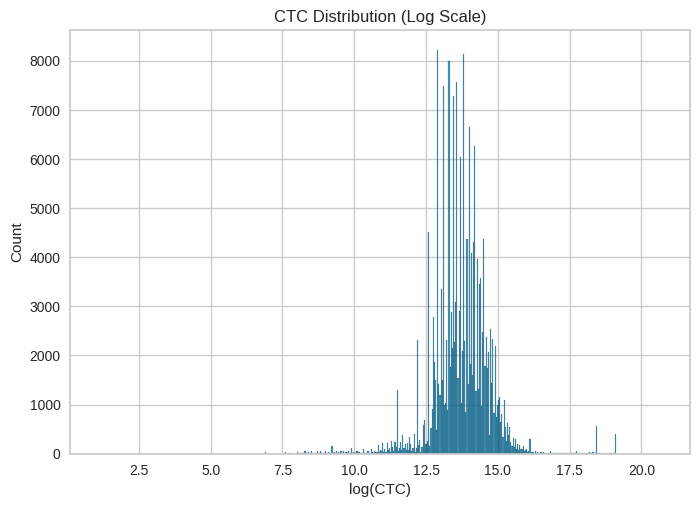

In [46]:
sns.histplot(np.log1p(df1['ctc']))  # log1p to avoid issues with log(0)
plt.xlabel('log(CTC)')
plt.title('CTC Distribution (Log Scale)')
plt.show()


In [47]:
# Calculate upper bound for ctc using 99th percentile
ctc_upper_bound = df1['ctc'].quantile(0.99)

# Apply clipping to ctc column
df1['ctc_capped'] = np.clip(df1['ctc'], df1['ctc'].min(), ctc_upper_bound)

In [48]:
# q1 = df1['ctc'].quantile(0.25)
# q3 = df1['ctc'].quantile(0.75)
# iqr = q3 - q1
# ctc_lower_bound = q1 - 1.5 * iqr
# ctc_upper_bound = q3 + 1.5 * iqr
# df1 = df1[(df1['ctc'] >= ctc_lower_bound) & (df1['ctc'] <= ctc_upper_bound)]

In [49]:
# ctc_outliers = df1[(df1['ctc'] < ctc_lower_bound) | (df1['ctc'] > ctc_upper_bound)]
# ctc_outliers

**ctc_updated_year**

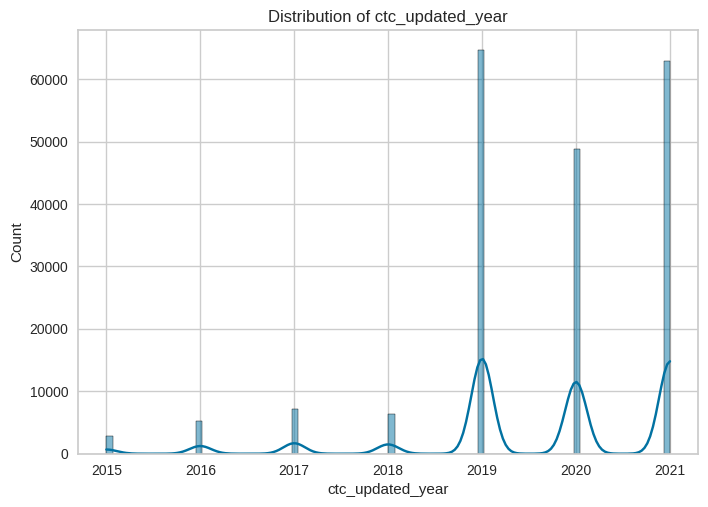

In [50]:
sns.histplot(df1['ctc_updated_year'], kde=True)  # kde=True adds smooth curve
plt.title('Distribution of ctc_updated_year')
plt.show()

**No Traditional Outliers:**

This is not a continuous numeric variable — it’s discrete year-based, so outliers (like in salaries) don’t directly apply.



In [51]:
df1.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,ctc_capped
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016,1100000,other,2020,1100000
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018,449999,fullstack engineer,2019,449999
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015,2000000,backend engineer,2020,2000000
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017,700000,backend engineer,2019,700000
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017,1400000,fullstack engineer,2019,1400000


**Categorical Columns**

**value_counts() to determine the rare categories**

**company_hash**

In [52]:
company_count = df1['company_hash'].value_counts().reset_index()
# company_count.columns = ['company_hash', 'count']
company_count

,company_hash,count
0,nvnv wgzohrnvzwj otqcxwto,8271
1,xzegojo,5304
2,vbvkgz,3424
3,zgn vuurxwvmrt vwwghzn,3266
4,wgszxkvzn,3157
...,...,...
35412,rvpyo,1
35413,mjz btrrgz ntwyzgrgsxt,1
35414,qq ofxen ogrhnxgzo,1
35415,ovbohzs ztdn,1


In [53]:
top_10_companies = company_count.head(10)
top_10_companies

,company_hash,count
0,nvnv wgzohrnvzwj otqcxwto,8271
1,xzegojo,5304
2,vbvkgz,3424
3,zgn vuurxwvmrt vwwghzn,3266
4,wgszxkvzn,3157
5,vwwtznhqt,2812
6,fxuqg rxbxnta,2623
7,gqvwrt,2335
8,bxwqgogen,2051
9,wvustbxzx,1994


In [54]:
# company_map = {
#     'nvnv wgzohrnvzwj otqcxwto': 'Tata Consultancy Services',
#     'xzegojo': 'Infosys',
#     'zgn vuurxwmrt vwwghzn': 'Accenture',
#     'wgszxkvzn': 'Cognizant',
#     'vwvtznhqt': 'Wipro',
#     'vbvkgz': 'IBM',
#     'fxuqg rxbxnta': 'Capgemini',
#     'gqvwrt': 'Tech Mahindra',
#     'wvustbzx': 'HCL',
#     'zvz': 'Deloitte'
# }
# df['company_name'] = df['company_hash'].map(company_map)

<Axes: xlabel='count', ylabel='Count'>

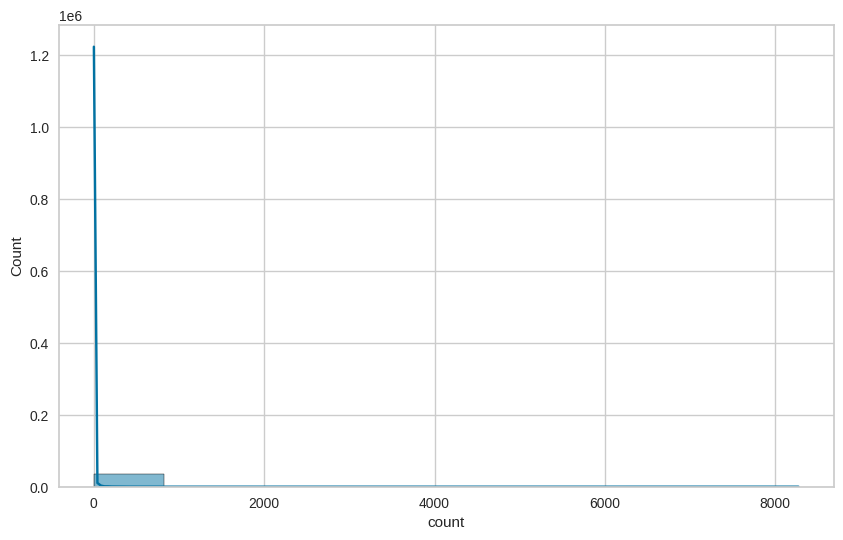

In [55]:
# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(company_count['count'], bins=10, kde=True)

**Companies with less than 5 frequency can be grouped into 'others' category**

In [56]:
rare_companies = set(company_count[company_count['count'] <= 5]['company_hash'])
df1['company_hash'] = df1['company_hash'].apply(lambda x: 'others' if x in rare_companies else x)

In [57]:
df1[df1['company_hash'] == 'others']

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,ctc_capped
2,others,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015,2000000,backend engineer,2020,2000000
9,others,b2dc928f4c22a9860b4a427efb8ab761e1ce0015fba1a5...,2019,360000,nan,2019,360000
11,others,72c2171a022115d475c8faac306912a4c95f6dd7fdd320...,2016,600000,ios engineer,2021,600000
16,others,26ec792de0792706df9beb9a8d37f45d732982e7ea21e2...,2013,800000,other,2020,800000
21,others,be9363f1468f242f655953b2f088922cb6cad80e62c493...,2006,1550000,engineering leadership,2019,1550000
...,...,...,...,...,...,...,...
205811,others,5feda7334a13c3f92937c0b3c4048aaab617edaf59ee4e...,2013,85000,nan,2016,85000
205815,others,6b163240ed6d31edd56950011b578d1cf255c7515c3f16...,2015,2400000,nan,2019,2400000
205816,others,ee1c076471293e4d5560508b3f7b2cb76e37dea88b74b6...,2019,2200000,nan,2020,2200000
205817,others,a74c83782bc88928dd12b103c09697fbef87d15bd308d3...,2011,3327000,nan,2019,3327000


In [58]:
df1.company_hash.value_counts()

,count
company_hash,
others,48563
nvnv wgzohrnvzwj otqcxwto,8271
xzegojo,5304
vbvkgz,3424
zgn vuurxwvmrt vwwghzn,3266
...,...
qxen sqghu,6
ctwngowvrvq,6
xsn ogrhnxgzo,6


**Adding experience**

In [59]:
df1['orgyear'].max()

2024

As the max value in orgyear is 2024, i would like to take 2024 at current year

In [60]:
# current_year = pd.Timestamp.now().year
current_year = 2024
df1['orgyear'] = df1['orgyear'].apply(lambda x: x if x <= current_year else current_year)
df1['experience'] = current_year - df1['orgyear']
df1['experience']

,experience
0,8.0
1,6.0
2,9.0
3,7.0
4,7.0
...,...
205838,16.0
205839,7.0
205840,3.0
205841,5.0


**Capping years of experience**

In [61]:
# Calculate upper bound for YOE using 99th percentile
yoe_upper_bound = df1['experience'].quantile(0.99)

# Apply clipping to YOE column
df1['exp_capped'] = np.clip(df1['experience'], df1['experience'].min(), yoe_upper_bound)

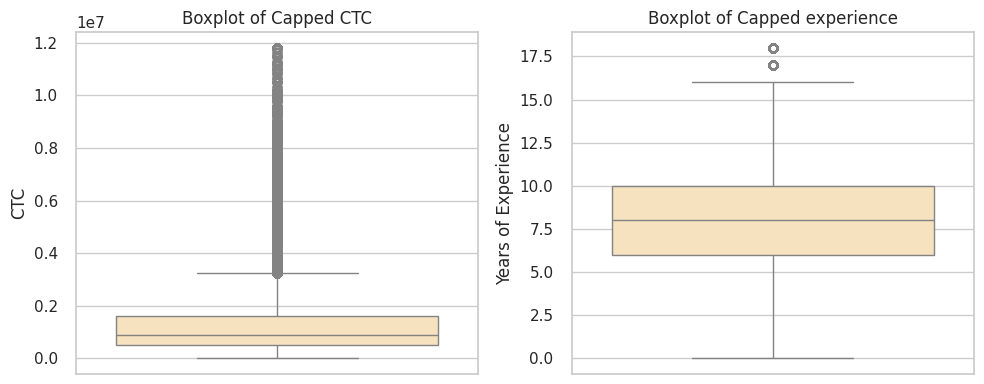

In [62]:
# Set the style of seaborn
sns.set(style="whitegrid")

# Create a figure with two subplots for CTC and YOE
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Boxplot for CTC post Capping
sns.boxplot(data=df1, y='ctc_capped', ax=ax[0],color='moccasin')
ax[0].set_title('Boxplot of Capped CTC')
ax[0].set_ylabel('CTC')

# Boxplot for YOE post Capping
sns.boxplot(data=df1, y='exp_capped', ax=ax[1],color='moccasin')
ax[1].set_title('Boxplot of Capped experience')
ax[1].set_ylabel('Years of Experience')

# Show the plots
plt.tight_layout()
plt.show()

**job_position**

In [63]:
job_count = df1['job_position'].value_counts().reset_index()
print(job_count)

                                          job_position  count
0                                                  nan  51259
1                                     backend engineer  42758
2                                   fullstack engineer  25483
3                                                other  17575
4                                    frontend engineer  10072
5                                          qa engineer   6254
6                                     android engineer   5299
7                                       data scientist   5179
8                                                 sdet   4849
9                               engineering leadership   4757
10                                     devops engineer   4377
11                                    support engineer   3543
12                                        data analyst   2855
13                                        ios engineer   2710
14                                  engineering intern   2690
15      

**cleaning job_position titles**

In [64]:
# df1['job_position'] = df1['job_position'].fillna('others') doesnt work because nan is not np.nan but string nan
df1['job_position'] = df1['job_position'].replace('nan', 'other')
# df1['job_position'] = df1['job_position'].replace('other', 'others')

In [65]:
def clean_text(text):
    text = text.lower()                    # Lowercase
    text = text.strip()                    # Remove leading/trailing whitespace
    text = re.sub(r'[^a-z\s]', '', text)   # Remove punctuation/special characters
    text = re.sub(r'\s+', ' ', text)       # Normalize whitespace
    return text
df1['job_cleaned'] = df1['job_position'].apply(clean_text)


**top 50 job titles**

In [66]:
df1['job_cleaned'].value_counts().reset_index()

,job_cleaned,count
0,other,68834
1,backend engineer,42758
2,fullstack engineer,25483
3,frontend engineer,10072
4,qa engineer,6254
5,android engineer,5299
6,data scientist,5179
7,sdet,4849
8,engineering leadership,4757
9,devops engineer,4377


In [67]:
# Now create the job_count DataFrame from df1, which now includes 'job_cleaned'
job_count = df1['job_cleaned'].value_counts().reset_index()
# Rename the columns for clarity if needed, but it's not strictly necessary for the fix
# job_count.columns = ['job_cleaned', 'count']

# Now get the top 50 jobs based on the cleaned job titles
top_50_jobs = job_count.head(51)

# Now you can safely create the set of top 50 job titles from the 'job_cleaned' column
top_50_jobtitles = set(top_50_jobs['job_cleaned'])
# top_50_jobtitles.discard('other')
print(top_50_jobtitles)

{'research engineers', 'engineering leadership', 'software engineer backend', 'lead software engineer', 'software engineer ii', 'research engineer', 'engineering intern', 'associate software engineer', 'data engineer', 'programmer analyst', 'associate', 'software development engineer', 'release engineer', 'fullstack engineer', 'other', 'program manager', 'software development engineer i', 'member of technical staff', 'backend engineer', 'product designer', 'project engineer', 'software engineer', 'intern', 'security leadership', 'non coder', 'support engineer', 'backend architect', 'database administrator', 'senior software developer', 'devops engineer', 'data analyst', 'cofounder', 'senior software engineer', 'assistant system engineer', 'data scientist', 'senior consultant', 'consultant', 'senior engineer', 'sdet', 'technology analyst', 'product manager', 'software developer', 'android engineer', 'ios engineer', 'sde', 'engineer', 'system engineer', 'qa engineer', 'software developme

**fuzzywuzzy**

In [68]:
!pip install fuzzywuzzy

In [69]:
from fuzzywuzzy import process

def find_closest_match(job, top_50_jobtitles, threshold=80):
    best_match, score = process.extractOne(job, top_50_jobtitles)
    return best_match if score >= threshold else 'other'

In [70]:
corrected_jobs = {}
for job in df1['job_cleaned'].unique():
  if pd.isna(job):
    corrected_jobs[job] = 'other'
  else:
    corrected_jobs[job] = find_closest_match(job, top_50_jobtitles)
df1['job_cleaned'] = df1['job_cleaned'].map(corrected_jobs)

In [71]:
df1['job_cleaned'].unique()

array(['other', 'fullstack engineer', 'backend engineer', 'ios engineer',
       'data analyst', 'frontend engineer', 'engineering leadership',
       'data scientist', 'engineering intern', 'android engineer',
       'qa engineer', 'research engineers', 'sdet', 'support engineer',
       'security leadership', 'devops engineer', 'product manager',
       'program manager', 'cofounder', 'member of technical staff',
       'product designer', 'system engineer', 'backend architect',
       'database administrator', 'senior software engineer',
       'release engineer', 'non coder', 'associate',
       'software development engineer', 'software engineer', 'engineer',
       'sde', 'project engineer', 'software development engineer i',
       'senior software developer', 'programmer analyst',
       'software engineer backend', 'student', 'senior engineer',
       'intern', 'associate software engineer', 'software engineer ii',
       'assistant system engineer', 'software development engi

**rapidfuzz**

In [72]:
# from rapidfuzz import process
# unique_jobs = df1['job_cleaned'].unique()
# corrected_jobs = {}

# for title in unique_jobs:
#     # Try to find a match in the existing mapped_titles keys
#     result = process.extractOne(title, corrected_jobs.keys(), score_cutoff=90)

#     # Check if a match was found above the cutoff
#     if result is not None:
#         match, score, _ = result
#         corrected_jobs[title] = match
#     else:
#         # If no match is found, map the title to itself
#         corrected_jobs[title] = title

# # Assuming df is the original dataframe you want to add the new column to
# # Make sure df is the correct dataframe where you want to add the 'job_grouped' column.
# # Based on the traceback, it seems you were trying to modify a variable named 'df',
# # which might be a different DataFrame than 'df1' at this point.
# # If you intend to add the column to df1, change df to df1 below.
# # I will assume you want to add it to df1 based on the previous steps modifying df1.
# df1['job_position'] = df1['job_position'].map(corrected_jobs)

In [73]:
df1[~(df1['job_cleaned'].isnull())]

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,ctc_capped,experience,exp_capped,job_cleaned
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020,1100000,8.0,8.0,other
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019,449999,6.0,6.0,fullstack engineer
2,others,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020,2000000,9.0,9.0,backend engineer
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019,700000,7.0,7.0,backend engineer
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019,1400000,7.0,7.0,fullstack engineer
...,...,...,...,...,...,...,...,...,...,...
205838,vuurt xzw,70027b728c8ee901fe979533ed94ffda97be08fc23f33b...,2008.0,220000,other,2019,220000,16.0,16.0,other
205839,husqvawgb,7f7292ffad724ebbe9ca860f515245368d714c84705b42...,2017.0,500000,other,2020,500000,7.0,7.0,other
205840,vwwgrxnt,cb25cc7304e9a24facda7f5567c7922ffc48e3d5d6018c...,2021.0,700000,other,2021,700000,3.0,3.0,other
205841,zgn vuurxwvmrt,fb46a1a2752f5f652ce634f6178d0578ef6995ee59f6c8...,2019.0,5100000,other,2019,5100000,5.0,5.0,other


In [74]:
df1.drop(columns=['job_position'],inplace=True)

# Manual Clustering based on company, job_position and experience

In [75]:
df2 = df1.copy()

In [76]:
# Drop original ctc and YOE columns
df2.drop(['ctc', 'experience'], axis=1, inplace=True)

In [77]:
comp_job_exp_df = df2.groupby(['company_hash', 'job_cleaned', 'exp_capped'])['ctc_capped'].agg(['mean', 'median', 'max', 'min', 'count']).reset_index()

In [78]:
comp_job_exp_df.rename(columns={'mean': 'mean_designation'}, inplace=True)

# Manual Clustering based on company and job position

In [79]:
comp_job_df=df2.groupby(['company_hash', 'job_cleaned'])['ctc_capped'].agg(['mean', 'median', 'max', 'min', 'count']).reset_index()

In [80]:
comp_job_df.rename(columns={'mean': 'mean_class'}, inplace=True)

# Manual Clustering based on company

In [81]:
comp_df=df2.groupby(['company_hash'])['ctc_capped'].agg(['mean', 'median', 'max', 'min', 'count']).reset_index()

In [82]:
comp_df.rename(columns={'mean': 'mean_tier'}, inplace=True)

**Merge only the mean values with the original dataset**

In [83]:
df2 = df2.merge(comp_job_exp_df[['company_hash', 'job_cleaned', 'exp_capped', 'mean_designation']], on=['company_hash', 'job_cleaned', 'exp_capped'])

In [84]:
df2 = df2.merge(comp_job_df[['company_hash', 'job_cleaned', 'mean_class']], on=['company_hash', 'job_cleaned'])

In [85]:
df2 = df2.merge(comp_df[['company_hash', 'mean_tier']], on=['company_hash'])

***Create Designation column based on salary ***

In [86]:
def designation_func(row):
    if row['ctc_capped'] > row['mean_designation']:
        return 3
    elif row['ctc_capped'] == row['mean_designation']:
        return 2
    else:
        return 1

In [87]:
def class_func(row):
    if row['ctc_capped'] > row['mean_class']:
        return 3
    elif row['ctc_capped'] == row['mean_class']:
        return 2
    else:
        return 1

In [88]:
def tier_func(row):
    if row['ctc_capped'] > row['mean_tier']:
        return 3
    elif row['ctc_capped'] == row['mean_tier']:
        return 2
    else:
        return 1

In [89]:
df2['Designation_Flag'] = df2.apply(designation_func, axis=1)
df2['Class_Flag'] = df2.apply(class_func, axis=1)
df2['Tier_Flag'] = df2.apply(tier_func, axis=1)

In [90]:
columns_to_drop = ['mean_class', 'mean_designation', 'mean_tier']
df2.drop(columns=[col for col in columns_to_drop if col in df2.columns], inplace=True)

In [91]:
df2.shape

(197863, 10)

In [92]:
comp_job_exp_df.head()

,company_hash,job_cleaned,exp_capped,mean_designation,median,max,min,count
0,a ntwyzgrgsxto,android engineer,10.0,710000.0,710000.0,710000,710000,1
1,a ntwyzgrgsxto,backend engineer,9.0,600000.0,600000.0,600000,600000,1
2,a ntwyzgrgsxto,backend engineer,10.0,600000.0,600000.0,600000,600000,1
3,a ntwyzgrgsxto,backend engineer,11.0,1350000.0,1350000.0,1350000,1350000,1
4,a ntwyzgrgsxto,frontend engineer,8.0,500000.0,500000.0,500000,500000,2


In [93]:
comp_job_df.head()

,company_hash,job_cleaned,mean_class,median,max,min,count
0,a ntwyzgrgsxto,android engineer,710000.0,710000.0,710000,710000,1
1,a ntwyzgrgsxto,backend engineer,850000.0,600000.0,1350000,600000,3
2,a ntwyzgrgsxto,frontend engineer,500000.0,500000.0,500000,500000,2
3,a ntwyzgrgsxto,fullstack engineer,485000.0,485000.0,620000,350000,2
4,a ntwyzgrgsxto,other,1815625.0,975000.0,4000000,350000,8


In [94]:
comp_df.head()

,company_hash,mean_tier,median,max,min,count
0,a ntwyzgrgsxto,1.234688e+06,600000.0,4000000,350000,16
1,aaqxctz avnv owxtzwto vzvrjnxwo ucn rna,9.850000e+05,500000.0,3600000,360000,8
2,adw ntwyzgrgsj,8.942210e+05,570000.0,11800000,32000,276
3,adw ntwyzgrgsxto,9.421603e+05,600000.0,11800000,100000,131
4,agdutq,1.666667e+06,1400000.0,2500000,800000,6


In [95]:
df2.head()

,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,2020,1100000,8.0,other,2,3,1
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,2019,449999,6.0,fullstack engineer,1,1,1
2,others,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2020,2000000,9.0,backend engineer,3,3,3
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,2019,700000,7.0,backend engineer,1,1,1
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,2019,1400000,7.0,fullstack engineer,2,3,3


**Desgination Flag**

**Top 10 and bottom 10 designations**

In [96]:
top_10_designation1 = df2[df2['Designation_Flag'] == 1].nlargest(10, 'ctc_capped')
top_10_designation1

,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
185570,vbvkgz ftm otqcxwto,0932dc8d855953b2ac63c8046c9fb33f7f554174b6c2fe...,2013.0,2019,11200000,11.0,backend engineer,1,3,3
11106,xzntr wgqugqvnxgz,306bd09e66cac5bd9b4d14475cb2f9510be780ae72b7af...,2013.0,2020,10000000,11.0,product manager,1,1,3
140500,vcvxr exzvzwt,88c5b2202f8df4de0fb0700e63418a6d2782bc09a097ec...,2015.0,2020,9300000,9.0,engineering leadership,1,1,3
60134,wrghaotp,1c77bd24643ff9dc2ff226f54f286ed00911625782248f...,2017.0,2020,9240000,7.0,other,1,3,3
186074,hmtq,9885423385b89dd905f1df74a1d6e71906ccccd915c7e4...,2013.0,2020,8500000,11.0,engineering leadership,1,3,3
80678,fvrbvqn rvmo,9adf861294aa69336409395a5474ce6f9ffbfd38594ed4...,2010.0,2019,8100000,14.0,backend architect,1,3,3
160885,sggsrt,24489565cc65a37e59b9d451890a221e04fe4bdc646d7b...,2022.0,2021,7500000,2.0,other,1,3,3
50223,ovoptz ntwyzgrgsxto rxbxnta,ca3f6f1d15c9daef5c614798b9da44bbf6e99abb20b09e...,2017.0,2018,7200000,7.0,other,1,3,3
147154,erxupvqn,aef1bf23fd33f27c961a92fd6078354861d4c77636c07d...,2009.0,2020,6600000,15.0,engineering leadership,1,3,3
82930,erxupvqn,394fffbe6d7c27a72903e8d926d4f0339a48801c4db867...,2014.0,2020,6500000,10.0,engineering leadership,1,1,3


In [97]:
bottom_10_designation3 = df2[df2['Designation_Flag'] == 3].nsmallest(10, 'ctc_capped')
bottom_10_designation3

,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
110417,xzntqcxtfmxn,23ad96d6b6f1ecf554a52f6e9b61677c7d73d8a409a143...,2013.0,2018,14,11.0,other,3,1,1
96238,nvrrj ogrhnxgzo ucn rna,711a490c61593b761e8436fe2bded36e5f7c5bdb7125fe...,2012.0,2019,21400,12.0,other,3,1,1
87242,tuvb ojontbo,1a696d351d5d246c4c6094c8466418155df679829b1b0b...,2016.0,2020,41000,8.0,frontend engineer,3,1,1
99014,ogwxn szqvrt,38e8416bc59782b9fb60b144657130662ec8dab8094a41...,2018.0,2021,55000,6.0,data scientist,3,1,1
190986,wtqz,217504679c19c4738eb44eacb651c80432d3a3801f62a5...,2014.0,2019,65000,10.0,fullstack engineer,3,3,1
87429,jvzatd,2f31b0f7d87048f22a9a6eb33526325d0b3f470185652b...,2019.0,2020,70000,5.0,backend engineer,3,1,1
75468,rvkvav sqghu,fcc04ea7359723c1ad0f9e39bb14b479bb904205e892cd...,2018.0,2017,95000,6.0,backend engineer,3,1,1
163054,rggpxzs egq v lgm,acfd76aab667b316f2039235354f6ccaf8fff9f992498c...,2017.0,2017,95000,7.0,other,3,1,1
47670,vnn,aa817b76d370ea737909b92697e7455d900b18fb1c3830...,2015.0,2019,97000,9.0,backend engineer,3,3,1
76004,mggpxzswgb,c8a5aacefbfba5fccf46968a7c2f54c45fc8f7e8c8a413...,2016.0,2017,100000,8.0,android engineer,3,3,1


**Class Flag**

In [98]:
top_10_class1_fs = df2[(df2['job_cleaned'] == 'fullstack engineer') & (df2['Class_Flag'] == 1)]
top_10_class1_fs = top_10_class1_fs.groupby('company_hash').apply(lambda x: x.nlargest(10, 'ctc_capped')).reset_index(drop=True)

Top 10 employees of FullStack Engineer in each company earning more than their peers - Class 1

In [99]:
top_10_class1_fs

,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
0,a ntwyzgrgsxto,0edd03cfabc907a9c062204678cd2e38e7ea60ae2d6422...,2021.0,2021,350000,3.0,fullstack engineer,2,1,1
1,adw ntwyzgrgsj,ce07b2e79fd7381b2f161bbe31feae30af2f5eeb8bf0a1...,2015.0,2019,956000,9.0,fullstack engineer,2,1,3
2,adw ntwyzgrgsj,ab74e3f64e4c4ab9d3b5706e7a2e17c98b5b39247d0266...,2013.0,2021,850000,11.0,fullstack engineer,2,1,1
3,adw ntwyzgrgsj,19fbc08c99a297dd82e1a0fe9fab62218c1a004bdb438f...,2016.0,2019,780000,8.0,fullstack engineer,3,1,1
4,adw ntwyzgrgsj,f0e6d4907243ac5b1adcbcab4722ec1e009ebaf8f9c37f...,2014.0,2020,760000,10.0,fullstack engineer,1,1,1
...,...,...,...,...,...,...,...,...,...,...
5365,zxzlvwvqn,9ded4a7c04c8044dd8e27dfd320bcb9c60d6a0f0d455da...,2019.0,2021,800000,5.0,fullstack engineer,2,1,1
5366,zxztrtvuo,af742fa47c46fa167ddfaf9c22a12a31cff23717582daa...,2018.0,2020,710000,6.0,fullstack engineer,3,1,1
5367,zxztrtvuo,af742fa47c46fa167ddfaf9c22a12a31cff23717582daa...,2018.0,2021,700000,6.0,fullstack engineer,1,1,1
5368,zxztrtvuo,b5628c03989a151f60c89e726351817c3a62078e7c70de...,2016.0,2019,575000,8.0,fullstack engineer,1,1,1


In [100]:
bottom_10_class3_fs = df2[(df2['job_cleaned'] == 'fullstack engineer') & (df2['Class_Flag'] == 3)]
bottom_10_class3_fs = bottom_10_class3_fs.groupby('company_hash').apply(lambda x: x.nsmallest(10, 'ctc_capped')).reset_index(drop=True)

Bottom 10 Employees of FullStack Engineer in Each Company Earning Less Than Their Peers - Class 3

In [101]:
bottom_10_class3_fs

,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
0,a ntwyzgrgsxto,1435d233c2bb40c762eb0a441822201600493dcff5706a...,2016.0,2019,620000,8.0,fullstack engineer,2,3,1
1,adw ntwyzgrgsj,bab01ffafe4aebcb11e6c835f4cfc05e200458680f59d7...,2011.0,2020,1300000,13.0,fullstack engineer,2,3,3
2,adw ntwyzgrgsj,f5c61ba407099401b400156a5da9e8ad1ddce7a8200199...,2008.0,2019,1400000,16.0,fullstack engineer,2,3,3
3,adw ntwyzgrgsj,667bc46030c674eadc0b5f5441b54780221d8e971edd33...,2012.0,2021,1400000,12.0,fullstack engineer,2,3,3
4,adw ntwyzgrgsj,95d152036530d88398d502ad18af95c9f6d5aee81ad15e...,2014.0,2021,1500000,10.0,fullstack engineer,3,3,3
...,...,...,...,...,...,...,...,...,...,...
4366,zxzlvwvqn,e2377e7ee0d53d2e3a45b9687fdc9c08b136b1dc470806...,2017.0,2020,2300000,7.0,fullstack engineer,3,3,3
4367,zxzlvwvqn,9002b19d0e582e7a807b96851505b9937bf8b696eaaa50...,2016.0,2021,4650000,8.0,fullstack engineer,3,3,3
4368,zxztrtvuo,650fd4e2b40bbc033df1c93c07f9b778ce8aa5d98e8292...,2016.0,2019,923000,8.0,fullstack engineer,3,3,1
4369,zxztrtvuo,077a6b1aa5195410e497d0fb91fe2627db85d9b9879ec7...,2016.0,2020,1200000,8.0,fullstack engineer,3,3,3


**Tier Flag**

Top 10 Employees Earning More Than Most of the Employees in the Company - Tier 1

In [102]:
top_10_tier1 = df2[df2['Tier_Flag'] == 1].nlargest(10, 'ctc_capped')

In [103]:
top_10_tier1

,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
93225,wvqttb,19839c1100097c37582a06a4dbb8ec28194883f0c6b70f...,2017.0,2020,5600000,7.0,backend engineer,1,1,1
157592,bgngqi,16561fc20ac2d6e9f1f88c3e1221b4ee99c6d0c8bc380e...,2020.0,2020,4100000,4.0,backend engineer,2,3,1
74975,ngftq qtotvqwy wvuxnvr,c546bc6e05341e4eff2a1185c27a478fda837ad5374837...,2018.0,2019,4000000,6.0,other,3,3,1
122152,ngftq qtotvqwy wvuxnvr,c546bc6e05341e4eff2a1185c27a478fda837ad5374837...,2018.0,2019,4000000,6.0,fullstack engineer,1,1,1
175069,vruyvsqtu otwhqxnxto,c9a7ee4dacc9545c6d06fccefbe10bb34ea96ff721a4fa...,2020.0,2020,4000000,4.0,other,2,3,1
134709,evzvnxwo xzw,272b4402a1a250ce5e285525023f79637cfd81c59d633d...,2011.0,2020,3950000,13.0,backend engineer,2,1,1
124518,hmtq,79412c42962f767443f735c5177b5bdf39d59c14363656...,2018.0,2019,3900000,6.0,fullstack engineer,3,1,1
146713,ngftq qtotvqwy wvuxnvr,f573013f4816cc7af668fb634124fd830471a872a2418a...,2018.0,2020,3900000,6.0,other,3,3,1
179153,ngftq qtotvqwy wvuxnvr,f39e6ff2e0952f4be4401229f2967988ae51368dcf2112...,2015.0,2019,3900000,9.0,backend engineer,3,3,1
150967,hmtq,b018ad514f3fefd6e717ec8895e150b2071c04878ea159...,2017.0,2020,3850000,7.0,backend engineer,3,1,1


Above List shows Top 10 employees details earning more than most of the employees of the company

**Top 10 Companies Based on Their CTC**

In [104]:
top_10_companies = df2.groupby('company_hash')['ctc_capped'].mean().nlargest(10).reset_index()

In [105]:
top_10_companies

,company_hash,ctc_capped
0,wvqttb,6.432654e+06
1,nyt sqtvn wghqoto,6.235556e+06
2,fgqraihvzn rrw,5.558333e+06
3,nyt fvrn axoztj wgbuvzj,5.233333e+06
4,wrghaotp,5.033000e+06
5,wgqt wgbutnt,4.908571e+06
6,axoy ztnfgqp,4.756250e+06
7,vxqugqno vhnygqxnj ge xzaxv,4.742857e+06
8,omx,4.650000e+06
9,onxrr onhatzn,4.517000e+06


**Top 2 positions in every company**

In [106]:
top_2_positions_per_comp = df2.groupby(['company_hash', 'job_cleaned'])['ctc_capped'].mean().reset_index()
top_2_positions_per_comp = top_2_positions_per_comp.groupby('company_hash').apply(lambda x: x.nlargest(2, 'ctc_capped')).reset_index(drop=True)

In [107]:
top_2_positions_per_comp

,company_hash,job_cleaned,ctc_capped
0,a ntwyzgrgsxto,other,1.815625e+06
1,a ntwyzgrgsxto,backend engineer,8.500000e+05
2,aaqxctz avnv owxtzwto vzvrjnxwo ucn rna,other,2.050000e+06
3,aaqxctz avnv owxtzwto vzvrjnxwo ucn rna,backend engineer,7.300000e+05
4,adw ntwyzgrgsj,product manager,5.000000e+06
...,...,...,...
6111,zxyxrtzn ntwyzgrgsxto,backend engineer,1.013333e+06
6112,zxzlvwvqn,product manager,4.800000e+06
6113,zxzlvwvqn,fullstack engineer,2.041667e+06
6114,zxztrtvuo,devops engineer,2.700000e+06


**Distribution of Designation, Class and Tier**

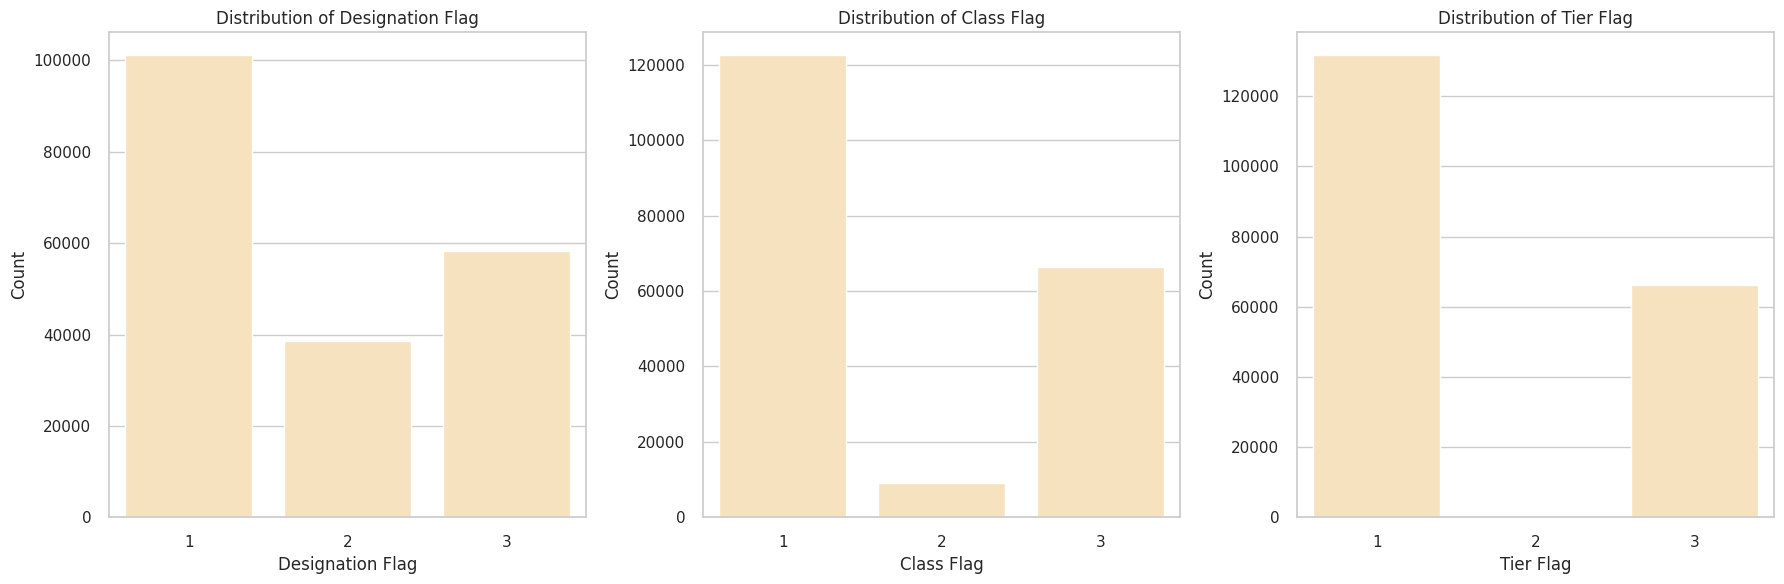

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot the distribution of Designation_Flag
sns.countplot(x='Designation_Flag', data=df2, ax=axes[0],color='moccasin')
axes[0].set_title('Distribution of Designation Flag')
axes[0].set_xlabel('Designation Flag')
axes[0].set_ylabel('Count')

# Plot the distribution of Class_Flag
sns.countplot(x='Class_Flag', data=df2, ax=axes[1],color='moccasin')
axes[1].set_title('Distribution of Class Flag')
axes[1].set_xlabel('Class Flag')
axes[1].set_ylabel('Count')

# Plot the distribution of Tier_Flag
sns.countplot(x='Tier_Flag', data=df2, ax=axes[2],color='moccasin')
axes[2].set_title('Distribution of Tier Flag')
axes[2].set_xlabel('Tier Flag')
axes[2].set_ylabel('Count')

# Display the plots
plt.tight_layout()
plt.show()

In [109]:
# Filter for Designation 1 learners
designation_1_learners = df2[df2['Designation_Flag'] == 1]

# Count learners in designation 1 for each job_position
designation_1_learners_count = designation_1_learners['job_cleaned'].value_counts().reset_index()
designation_1_learners_count.columns = ['job_cleaned', 'count']

# Top job_positions with Designation 1
top_designation_1_learners = designation_1_learners_count.head(10)
print(top_designation_1_learners)

              job_cleaned  count
0                   other  40843
1        backend engineer  21982
2      fullstack engineer  13038
3       frontend engineer   4500
4             qa engineer   2859
5        android engineer   2532
6          data scientist   2045
7                    sdet   1916
8        support engineer   1908
9  engineering leadership   1702


In [110]:
designation_2_learners = df2[df2['Designation_Flag'] == 2]

# Count learners in designation 1 for each job_position
designation_2_learners_count = designation_2_learners['job_cleaned'].value_counts().reset_index()
designation_2_learners_count.columns = ['job_cleaned', 'count']

# Top job_positions with Designation 1
top_designation_2_learners = designation_2_learners_count.head(10)
print(top_designation_2_learners)

              job_cleaned  count
0                   other   7584
1        backend engineer   6006
2      fullstack engineer   4440
3       frontend engineer   2851
4             qa engineer   1989
5  engineering leadership   1826
6          data scientist   1818
7                    sdet   1716
8         devops engineer   1663
9        android engineer   1405


The above are the job positions under designation 2

We dont notice any specific trend

**Tier Flag**

**companies dominate in Tier 1**

In [111]:
# Filter for Tier 1 learners
tier_1_learners = df2[df2['Tier_Flag'] == 1]

# Count learners in Tier 1 for each company
tier_1_company_counts = tier_1_learners['company_hash'].value_counts().reset_index()
tier_1_company_counts.columns = ['company_hash', 'count']

# Top companies in Tier 1
top_tier_1_companies = tier_1_company_counts.head(10)
print(top_tier_1_companies)

                company_hash  count
0                     others  33988
1  nvnv wgzohrnvzwj otqcxwto   5868
2                    xzegojo   3745
3     zgn vuurxwvmrt vwwghzn   2476
4                  wgszxkvzn   2411
5                  vwwtznhqt   2105
6              fxuqg rxbxnta   2076
7                     vbvkgz   2019
8                     gqvwrt   1498
9                  wvustbxzx   1387


Most of the learners are from the companies that are segmented as others

The others company category has many learners whose job position has not been mentioned

They may be from different industries or different domains like mechanical core companies or electronics core domains etc etc

In [112]:
# Filter for Tier 3 learners
tier_3_learners = df2[df2['Tier_Flag'] == 3]

# Count learners in Tier 3 for each company
tier_3_company_counts = tier_3_learners['company_hash'].value_counts().reset_index()
tier_3_company_counts.columns = ['company_hash', 'count']

# Top companies in Tier 1
top_tier_3_companies = tier_3_company_counts.head(10)
print(top_tier_3_companies)

                company_hash  count
0                     others  14575
1  nvnv wgzohrnvzwj otqcxwto   2403
2                    xzegojo   1559
3                     vbvkgz   1405
4                  bxwqgogen    840
5                     gqvwrt    837
6     zgn vuurxwvmrt vwwghzn    790
7                  wgszxkvzn    746
8                  vwwtznhqt    707
9                  wvustbxzx    607


In [113]:
others_df = df2[df2['company_hash'] == 'others']

In [114]:
others_df['job_cleaned'].value_counts().head(20)

,count
job_cleaned,
other,14602
backend engineer,7869
fullstack engineer,6625
frontend engineer,3228
android engineer,2738
data scientist,1802
qa engineer,1781
engineering leadership,1558
ios engineer,1372


Companies who have appeared less frequently have the highest job_positions bearing 'others' but still come under under Tier 1. These could most probabilistically be from non-IT domains.

In [115]:
# Filter for Tier 3 learners
tier_3_learners = df2[df2['Tier_Flag'] == 3]

# Count learners in Tier 3 for each company
tier_3_company_counts = tier_3_learners['company_hash'].value_counts().reset_index()
tier_3_company_counts.columns = ['company_hash', 'count']

# Top companies in Tier 3
top_tier_3_companies = tier_3_company_counts.head(10)
print(top_tier_3_companies)

                company_hash  count
0                     others  14575
1  nvnv wgzohrnvzwj otqcxwto   2403
2                    xzegojo   1559
3                     vbvkgz   1405
4                  bxwqgogen    840
5                     gqvwrt    837
6     zgn vuurxwvmrt vwwghzn    790
7                  wgszxkvzn    746
8                  vwwtznhqt    707
9                  wvustbxzx    607


1. **"Others" dominates both tiers**

*   Tier 1 "others": 28,333 learners

*   Tier 3 "others": 18,422 learners

This means most learners come from small or infrequent companies across all tiers.

**Implication:**

You need independent clustering within the "others" category to uncover meaningful segments (e.g., by job title, domain, skills).


2. **Some companies are strong across tiers**

A few company_hash values appear in both Tier 1 and Tier 3:



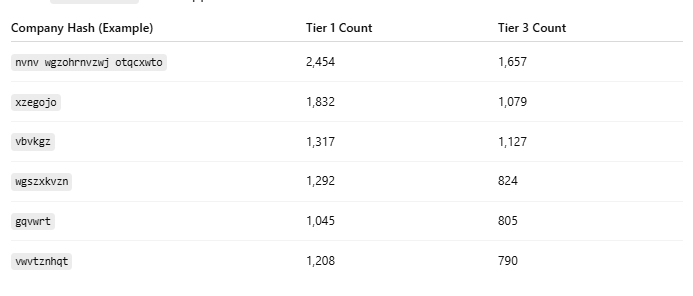

3. **Engagement funnel potential**

Since top companies have learners in both Tier 1 and Tier 3, you can:

Analyze what features Tier 1 learners used that helped them succeed.

Use those patterns to guide Tier 3 learners in similar companies.

Personalization Strategy:
Create tier-specific nudges or interventions for Tier 3 learners based on success stories from Tier 1 of the same company.

4. **Corporate Upskilling Strategy**

Companies like 'nvnv wgzohrnvzwj otqcxwto' and 'xzegojo' have high learner counts and cross-tier presence.

These are ideal candidates for partnerships, offering:

Cohort-based learning

Leaderboard-based gamification within company

Company-wide performance dashboards

**Summary Statistics**

In [116]:
designation_summary = df2.groupby('Designation_Flag')['ctc_capped'].describe()
class_summary = df2.groupby('Class_Flag')['ctc_capped'].describe()
tier_summary = df2.groupby('Tier_Flag')['ctc_capped'].describe()

In [117]:
designation_summary

,count,mean,std,min,25%,50%,75%,max
Designation_Flag,,,,,,,,
1,101072.0,7.715959e+05,5.826814e+05,2.0,400000.0,600000.0,1000000.0,11200000.0
2,38615.0,1.524578e+06,1.573625e+06,1000.0,670000.0,1100000.0,1800000.0,11800000.0
3,58176.0,2.245013e+06,2.150039e+06,14.0,1050000.0,1600000.0,2500000.0,11800000.0


In [118]:
class_summary

,count,mean,std,min,25%,50%,75%,max
Class_Flag,,,,,,,,
1,122461.0,7.711797e+05,5.450403e+05,2.0,400000.0,650000.0,1000000.00,10000000.0
2,9134.0,1.480107e+06,1.565799e+06,1000.0,650000.0,1000000.0,1789999.75,11800000.0
3,66268.0,2.406976e+06,2.150505e+06,14000.0,1200000.0,1800000.0,2700000.00,11800000.0


In [119]:
tier_summary

,count,mean,std,min,25%,50%,75%,max
Tier_Flag,,,,,,,,
1,131645.0,7.595331e+05,4.963317e+05,2.0,400000.0,650000.0,1000000.0,5600000.0
2,19.0,5.578947e+05,2.735686e+05,300000.0,300000.0,450000.0,840000.0,1000000.0
3,66199.0,2.529719e+06,2.163930e+06,159000.0,1350000.0,1900000.0,2850000.0,11800000.0


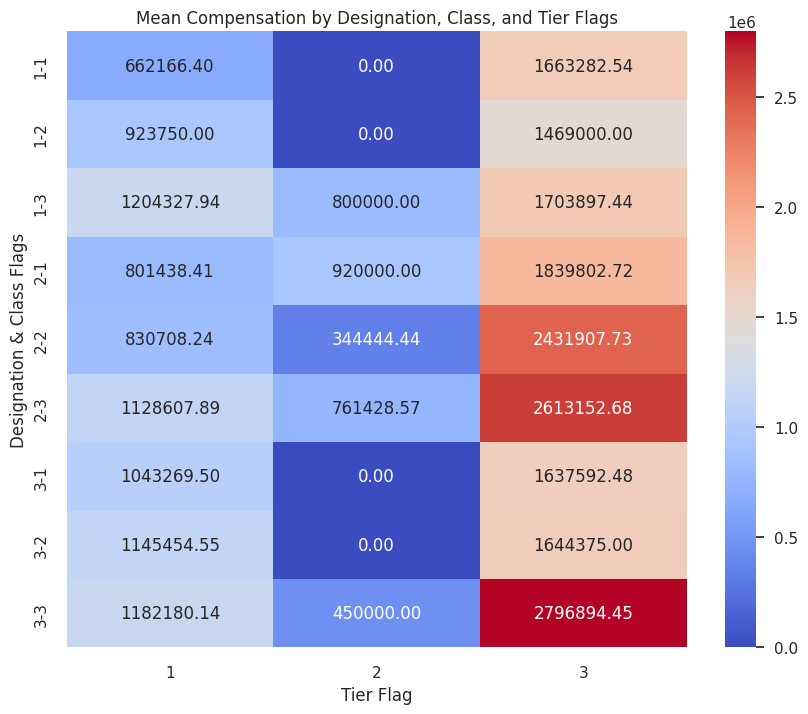

In [120]:
# Mean compensation by flags
mean_compensation_flags = df2.groupby(['Designation_Flag', 'Class_Flag', 'Tier_Flag'])['ctc_capped'].mean().unstack().fillna(0)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(mean_compensation_flags, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mean Compensation by Designation, Class, and Tier Flags')
plt.xlabel('Tier Flag')
plt.ylabel('Designation & Class Flags')
plt.show()

**📌 Recommendations / Business Insights:**
📈 Tier 3 companies are dominant in driving compensation premium, especially in experienced roles.

🔎 Address data gaps in Tier 2 for more reliable modeling.

🎯 Designation-Class 2.3 and 3.3 are key target groups for attracting senior talent.

🧭 Consider using this data to design competitive compensation bands or job clustering models.



**Cross Tabulation Analysis**

Examining the relationship between these flags can reveal if there are patterns or dependencies among them.

In [121]:
designation_class_ct = pd.crosstab(df2['Designation_Flag'], df2['Class_Flag'], normalize='index')
designation_tier_ct = pd.crosstab(df2['Designation_Flag'], df2['Tier_Flag'], normalize='index')
class_tier_ct = pd.crosstab(df2['Class_Flag'], df2['Tier_Flag'], normalize='index')

print("Cross-Tabulation between Designation Flag and Class Flag:\n", designation_class_ct)
print("\nCross-Tabulation between Designation Flag and Tier Flag:\n", designation_tier_ct)
print("\nCross-Tabulation between Class Flag and Tier Flag:\n", class_tier_ct)

Cross-Tabulation between Designation Flag and Class Flag:
 Class_Flag               1         2         3
Designation_Flag                              
1                 0.911657  0.000257  0.088086
2                 0.410281  0.235168  0.354551
3                 0.248814  0.000464  0.750722

Cross-Tabulation between Designation Flag and Tier Flag:
 Tier_Flag                1         2         3
Designation_Flag                              
1                 0.903831  0.000010  0.096159
2                 0.588372  0.000440  0.411187
3                 0.302066  0.000017  0.697917

Cross-Tabulation between Class Flag and Tier Flag:
 Tier_Flag          1         2         3
Class_Flag                              
1           0.949127  0.000008  0.050865
2           0.591964  0.000985  0.407051
3           0.151008  0.000136  0.848856


✅ **Insights: Designation vs class**

Designation 1 (likely junior-level) mostly belongs to Class 1 (low class).

Designation 3 (likely senior-level) overwhelmingly belongs to Class 3.

Designation 2 (mid-level) is distributed more evenly, showing a transition group.

Interpretation: There's a strong correlation between designation and class — higher designation aligns with higher class.


✅ **Insights: Designation vs Tier**

Designation 1 is dominant in Tier 1.

Designation 3 is dominant in Tier 3.

Designation 2 is a blend — showing progression or decline depending on features.

**Interpretation:**

Learners with higher designations tend to be in lower-performing tiers, which may indicate role stagnation or skill mismatch.

✅ **Insights: Tier vs Class**

Class 1 learners are nearly all in Tier 1 — highest performers.

Class 3 learners are mostly in Tier 3 — struggling or less engaged.

Class 2 learners show mixed performance, likely needing guidance.

**Interpretation:**

Class flag is a good predictor of learning tier — it could be derived from metrics like performance, attendance, or activity.

✅ **Summary for Personalization:**

These relationships can help:

Personalize content or learning paths based on a user’s designation and company tier

Align difficulty level or topics for different learner segments (e.g., Tier 3 + Designation 3 → Beginner material)

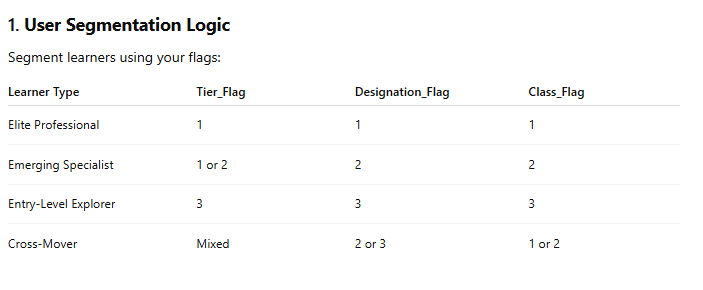

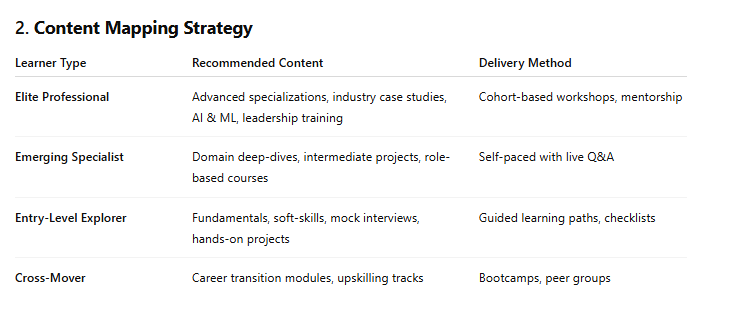

3. **Dynamic Recommendation Flow**

In [122]:
# def recommend_content(tier, designation, class_flag):
#     if tier == 1 and designation == 1 and class_flag == 1:
#         return "Advanced AI Projects, Leadership Series, Career Mentoring"
#     elif tier in [1, 2] and designation == 2:
#         return "Intermediate Skill Courses, Domain Certifications"
#     elif tier == 3 and designation == 3:
#         return "Beginner Bootcamps, Resume & Soft Skills, Foundation Modules"
#     else:
#         return "Career Track Courses, Cross-skilling Programs"
# recommend_content(1, 1, 1)

In [123]:
df3 = df2.copy()

In [124]:
# def recommend_learning_path(row):
#     tier = row['Tier_Flag']
#     designation = row['Designation_Flag']
#     class_flag = row['Class_Flag']

#     if tier == 1 and designation == 1 and class_flag == 1:
#         return "Advanced AI Projects, Leadership Series, Career Mentoring"
#     elif tier in [1, 2] and designation == 2:
#         return "Intermediate Skill Courses, Domain Certifications"
#     elif tier == 3 and designation == 3:
#         return "Beginner Bootcamps, Resume & Soft Skills, Foundation Modules"
#     else:
#         return "Career Track Courses, Cross-skilling Programs"


In [125]:
# df3['recommendation'] = df3.apply(recommend_learning_path, axis=1)

In [126]:
# df3[['Tier_Flag', 'Designation_Flag', 'Class_Flag', 'recommendation']].head(10)

## Exploratory Data Analysis

**Categorical Feature Distribution**

In [127]:
obj_cols= ['company_hash', 'job_cleaned','orgyear']

In [128]:
num_cols= ['ctc_capped','exp_capped']

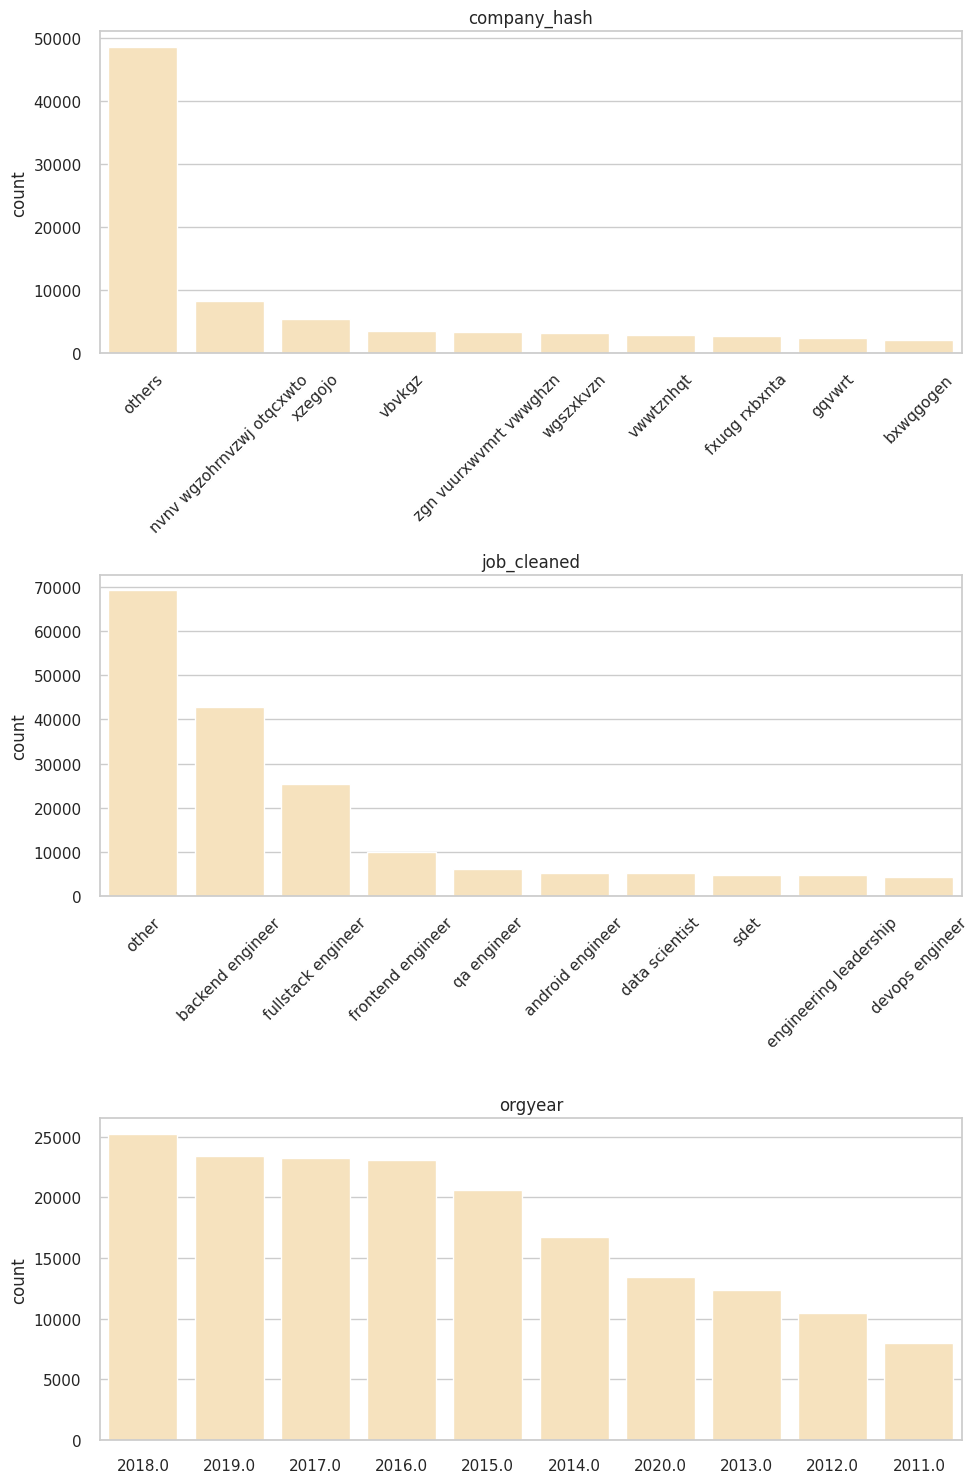

In [129]:
plt.figure(figsize=(10, 15))

i = 1
for col in obj_cols:
    # Get the top 10 values for the column
    top_10 = df3[col].value_counts().nlargest(10)
    top_10_index = top_10.index

    ax = plt.subplot(3, 1, i)
    sns.countplot(x=df3[col], order=top_10_index, color='moccasin')
    plt.title(f'{col}')
    if i <= 2:
        plt.xticks(rotation=45)

    ax.set_xlabel('')
    i += 1

plt.tight_layout()
plt.show()

**Numerical Feature Distribution**

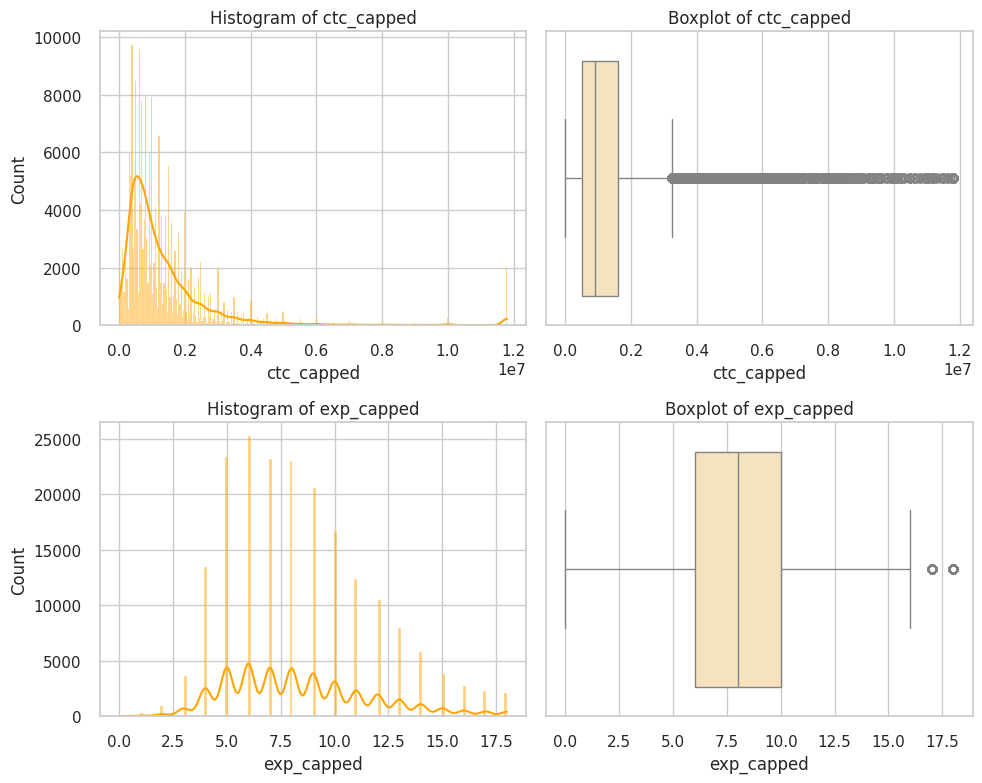

In [130]:
plt.figure(figsize=(10, 8))

# Loop through each numerical column and plot histogram and boxplot
for i, col in enumerate(num_cols):
    # Histogram
    ax1 = plt.subplot(2, 2, 2*i + 1)
    sns.histplot(df3[col], kde=True, color='orange')
    plt.title(f'Histogram of {col}')

    # Boxplot
    ax2 = plt.subplot(2, 2, 2*i + 2)
    sns.boxplot(x=df3[col], color='moccasin')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**CTC vs Years of Experience**

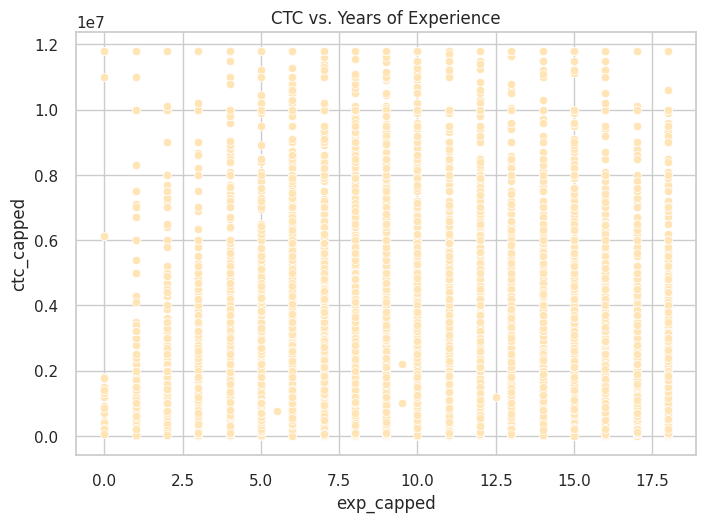

In [131]:
sns.scatterplot(x='exp_capped', y='ctc_capped', data=df3, color='moccasin')
plt.title('CTC vs. Years of Experience')
plt.show()

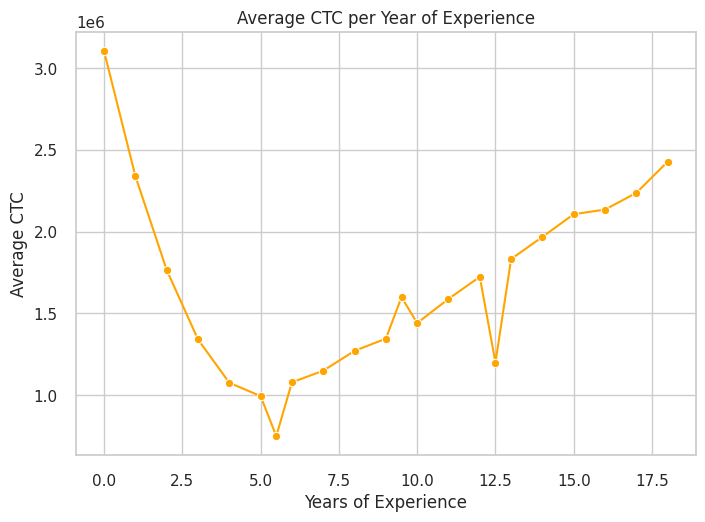

In [132]:
# Calculate average CTC per year of experience
avg_ctc_per_yoe = df3.groupby('exp_capped')['ctc_capped'].mean().reset_index()

# Line plot with markers
sns.lineplot(x='exp_capped', y='ctc_capped', data=avg_ctc_per_yoe, marker='o', color='orange')
plt.title('Average CTC per Year of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Average CTC')

plt.show()

**Q. Name job position that is commonly considered entry-level but has a few learners with unusually high CTCs in the dataset.**

In [133]:
title_summary = df3.groupby('job_cleaned').agg(
    count=('ctc_capped', 'count'),
    avg_ctc=('ctc_capped', 'mean'),
    max_ctc=('ctc_capped', 'max'),
    pct95_ctc=('ctc_capped', lambda x: np.percentile(x, 95)),
    median_ctc=('ctc_capped', 'median')
).sort_values(by='count', ascending=False)

In [134]:
entry_keywords = ['intern', 'trainee', 'junior', 'associate', 'assistant', 'entry', 'fresher', 'graduate',
                  'Entry Level Engineer']

def is_entry_level(title):
    return any(keyword in title for keyword in entry_keywords)

entry_roles = title_summary[title_summary.index.to_series().apply(is_entry_level)]

# Now find roles with unusually high CTC outliers
suspicious_roles = entry_roles[entry_roles['pct95_ctc'] > 2000000]  # threshold in INR


In [135]:
for role in suspicious_roles.index:
    print(f"\n🔍 {role.upper()} — Count: {entry_roles.loc[role]['count']}")
    display(df3[df3['job_cleaned'] == role].sort_values(by='ctc_capped', ascending=False).head(5))


🔍 ENGINEERING INTERN — Count: 2692.0


,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
941,gnytq,317dd00cd99c43f133ff80197d7c19ec6b82a28855a530...,2017.0,2020,11800000,7.0,engineering intern,2,3,3
59441,others,6ba3c95c64ea560de4320cf48a80458cb42ddf5d097c9f...,2023.0,2020,11800000,1.0,engineering intern,3,3,3
78832,yxzahonvz utnqgrthb wgqugqvnxgz rxbxnta,e89e7613237a02adaf10d346ddaa86df33fffc9ef6d05c...,2018.0,2019,11800000,6.0,engineering intern,3,3,3
78747,xzegojo,e10548c4596ac94b507d357f932c364b75f102da25ab75...,2020.0,2019,11800000,4.0,engineering intern,3,3,3
6741,others,759ff0c2576791d7f21b860726c2046c59e983fe18fc92...,2016.0,2020,11800000,8.0,engineering intern,3,3,3



🔍 ASSOCIATE — Count: 117.0


,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
79484,bvptbjnqxuwgb,791460f38917a8336c1db4bbb31bf14bef449cef450084...,2011.0,2019,7000000,13.0,associate,2,2,3
45297,otqcxwtzgf,a0474c4394ae79d021218663a3a9da9bea77c5c0dd24ec...,2012.0,2020,5300000,12.0,associate,2,3,3
111573,otqcxwtzgf,d44da287342d53668cd88a9831b67bc845a11a04adf39f...,2015.0,2020,4700000,9.0,associate,2,1,3
131141,bowx xzw,02ea4f73bdad9ae5ce94c555c728a0f709a638907c66e5...,2007.0,2019,3400000,17.0,associate,2,2,3
77925,uhmrxwxo ovuxtzn,fb4d3f58bfff8912fdc0a6211ca93418655afc7fb2bb43...,2016.0,2021,3100000,8.0,associate,2,3,3



🔍 INTERN — Count: 68.0


,company_hash,email_hash,orgyear,ctc_updated_year,ctc_capped,exp_capped,job_cleaned,Designation_Flag,Class_Flag,Tier_Flag
122279,others,2f8a345f3cc5f7b69a3c1a9bdafbf04bc6d831518b48ec...,2017.0,2016,11000000,7.0,intern,2,3,3
98935,gqvwrt,317d62782f1a3519bab1bb77f299c29e6a81c1104cbead...,2015.0,2021,3850000,9.0,intern,2,3,3
75453,sggsrt,1da579902fdd469685cddea5a4b453e42c4d260050ac7f...,2017.0,2015,3700000,7.0,intern,2,2,3
111705,vbvkgz,07843d952b8bce9900545d95854f9d963fd7a77581ed07...,2016.0,2019,3700000,8.0,intern,3,3,3
100680,wgat zxzlv wg,ee784087d9404d69d9ec40b1d4e303a557925b8675289d...,2021.0,2021,3400000,3.0,intern,2,2,3


**Q. What is the average CTC of learners across different job positions?**

In [136]:
# Group by job position and calculate the average CTC
average_ctc_by_position = df3.groupby('job_cleaned')['ctc_capped'].mean().reset_index()

# Rename the columns for clarity
average_ctc_by_position.columns = ['job_capped', 'average_ctc']

# Sort the result by average CTC in descending order
average_ctc_by_position = average_ctc_by_position.sort_values(by='average_ctc', ascending=False)

# Print the result
print(average_ctc_by_position)

                          job_capped   average_ctc
4                  backend architect  2.804925e+06
15            engineering leadership  2.565318e+06
41     software development engineer  2.274936e+06
25                   product manager  2.222537e+06
43  software development engineer ii  2.200500e+06
26                   program manager  2.133205e+06
33                               sde  2.023778e+06
20            lead software engineer  1.871308e+06
6                          cofounder  1.859770e+06
35               security leadership  1.766837e+06
42   software development engineer i  1.725789e+06
36                 senior consultant  1.722353e+06
39          senior software engineer  1.656956e+06
44                 software engineer  1.624206e+06
30                  release engineer  1.623568e+06
21         member of technical staff  1.605149e+06
31                 research engineer  1.603409e+06
46              software engineer ii  1.586757e+06
37                   senior eng

**Q.For a given company, how does the average CTC of a Data Scientist compare**
**with other roles?**

In [137]:
df3.columns

Index(['company_hash', 'email_hash', 'orgyear', 'ctc_updated_year',
       'ctc_capped', 'exp_capped', 'job_cleaned', 'Designation_Flag',
       'Class_Flag', 'Tier_Flag'],
      dtype='object')

In [138]:
# Filter the dataframe for rows where job_position is 'Data Scientist'
data_scientist_df = df3[df3['job_cleaned'] == 'data scientist']

# Get the unique companies that have the job position 'Data Scientist'
companies_with_data_scientist = data_scientist_df['company_hash'].unique()

# Print the result
print("Companies with 'Data Scientist' job position:")
print(companies_with_data_scientist)

Companies with 'Data Scientist' job position:
['others' 'tqxwoogz' 'xzntrrtwn atoxsz vqtzv rna' ... 'vaxnjv mxqrv sqghu'
 'utgurt xzntqvwnxct' 'yjhzavx bgmxo']


In [139]:
results = []

for company in companies_with_data_scientist:
    company_df = df3[df3['company_hash'] == company]

    ds_df = company_df[company_df['job_cleaned'].str.contains('data scientist', case=False, na=False)]
    other_df = company_df[~company_df['job_cleaned'].str.contains('data scientist', case=False, na=False)]

    # Ensure there's data to compute
    if not ds_df.empty and not other_df.empty:
        avg_ctc_ds = ds_df['ctc_capped'].mean()
        avg_ctc_other = other_df['ctc_capped'].mean()
        count_ds = len(ds_df)
        count_other = len(other_df)
        diff = avg_ctc_ds - avg_ctc_other
        pct_diff = (diff / avg_ctc_other) * 100 if avg_ctc_other else 0

        results.append({
            'company_hash': company,
            'avg_ctc_data_scientist': avg_ctc_ds,
            'avg_ctc_other_roles': avg_ctc_other,
            'ctc_diff': diff,
            'pct_diff': pct_diff,
            'count_ds': count_ds,
            'count_other': count_other
        })

# Convert to DataFrame
comparison_df = pd.DataFrame(results)


In [140]:
comparison_df

,company_hash,avg_ctc_data_scientist,avg_ctc_other_roles,ctc_diff,pct_diff,count_ds,count_other
0,others,1.319310e+06,1.188029e+06,1.312808e+05,11.050296,1802,46761
1,tqxwoogz,1.554760e+06,1.113428e+06,4.413316e+05,39.637179,25,307
2,xzntrrtwn atoxsz vqtzv rna,6.300000e+05,9.162675e+05,-2.862675e+05,-31.242788,3,154
3,vbagwo,7.475000e+05,9.871632e+05,-2.396632e+05,-24.277968,4,888
4,mxkvwhxnj ogrhnxgzo,8.400000e+05,7.488889e+05,9.111111e+04,12.166172,1,9
...,...,...,...,...,...,...,...
997,gatoov,6.850000e+05,9.234211e+05,-2.384211e+05,-25.819322,1,19
998,vxqntr drvmo,2.200000e+06,2.334933e+06,-1.349333e+05,-5.778894,1,30
999,vaxnjv mxqrv sqghu,2.900000e+06,9.833333e+05,1.916667e+06,194.915254,1,18
1000,utgurt xzntqvwnxct,8.000000e+05,1.460000e+06,-6.600000e+05,-45.205479,1,5


**CTC by Job Position**

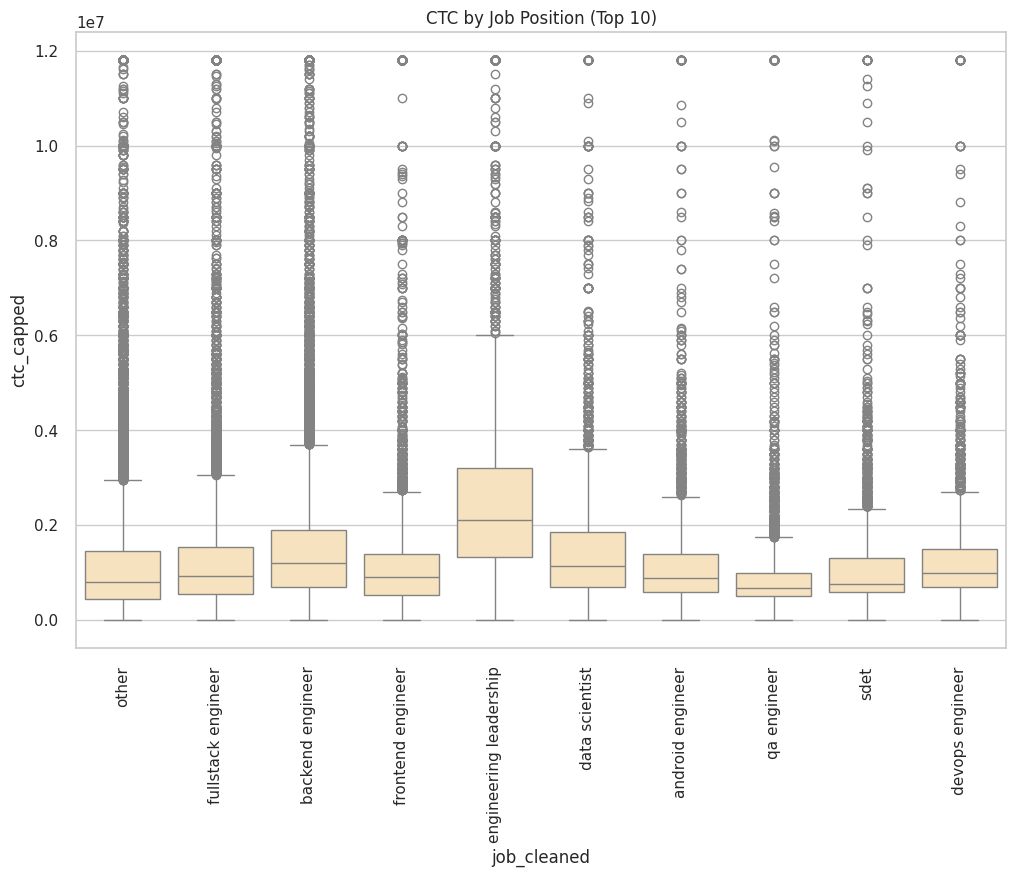

In [141]:
# Get the top 10 job positions by count
top_10_job_positions = df3['job_cleaned'].value_counts().nlargest(10).index

# Filter the dataset to include only the top 10 job positions
df_top_10 = df3[df3['job_cleaned'].isin(top_10_job_positions)]

# Plot the box plot for CTC by Job Position
plt.figure(figsize=(12, 8))
sns.boxplot(x='job_cleaned', y='ctc_capped', data=df_top_10, color='moccasin')
plt.xticks(rotation=90)
plt.title('CTC by Job Position (Top 10)')
plt.show()

CTC is highest for Engineering Leadership followed by Backend Engineer and Data Scientist

**Years of Experience by Job Position**

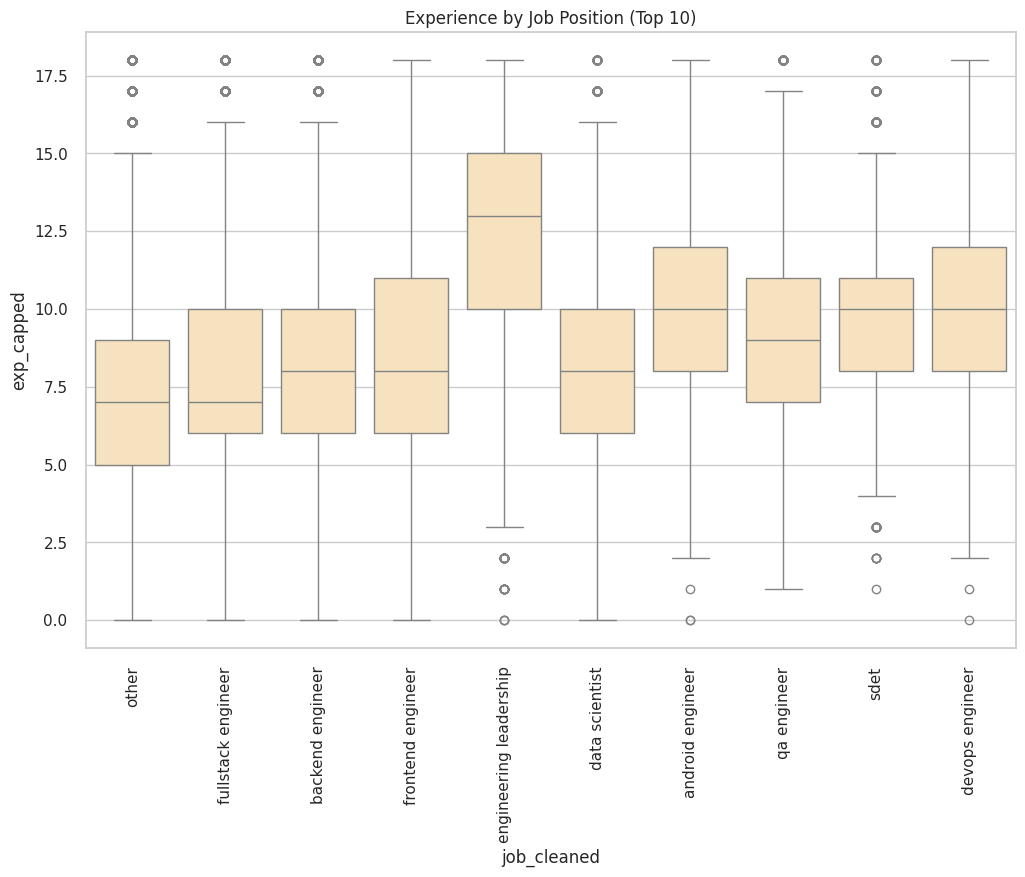

In [142]:
# Get the top 10 job positions by count
top_10_job_positions = df3['job_cleaned'].value_counts().nlargest(10).index

# Filter the dataset to include only the top 10 job positions
df_top_10 = df3[df3['job_cleaned'].isin(top_10_job_positions)]

# Plot the box plot for YOE by Job Position
plt.figure(figsize=(12, 8))
sns.boxplot(x='job_cleaned', y='exp_capped', data=df_top_10,color='moccasin')
plt.xticks(rotation=90)
plt.title('Experience by Job Position (Top 10)')
plt.show()

Years of Experience is highest for Engineering Leadership followed by Android Engineer and backend, frontend and SDET

**Correlation Heatmap**

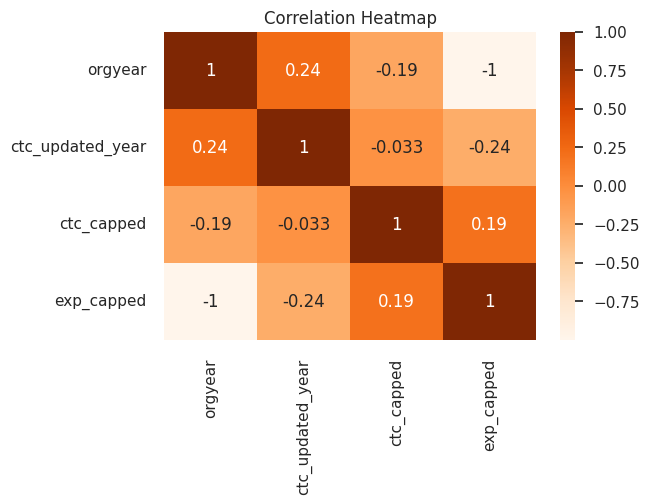

In [143]:
plt.figure(figsize=(6, 4))
sns.heatmap(df3[['orgyear', 'ctc_updated_year', 'ctc_capped', 'exp_capped']].corr(), annot=True, cmap='Oranges')
plt.title('Correlation Heatmap')
plt.show()

- orgyear and ctc_updated_year shown weak positive correlation
- Years of Experience and orgyear show strong negative correlation
- Years of Experience and CTC show weak positive correaltion

**Statistical Summary**

In [144]:
df['company_hash'].nunique()

37299

In [145]:
df3.describe(include='object')

,company_hash,email_hash,job_cleaned
count,197863,197863,197863
unique,3078,146790,51
top,others,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,other
freq,48563,10,69187


#Data Processing for Unsupervised Learning

- Encoding
- Scaling
- Feature Engineering
- Log Transformation

In [146]:
df4=df3.drop(['Designation_Flag', 'Class_Flag', 'Tier_Flag'], axis=1)

In [147]:
dfcopy=df.copy()

In [148]:
# Calculate frequency of email_hash in dfcopy
email_hash_freq = dfcopy['email_hash'].value_counts().reset_index()
email_hash_freq.columns = ['email_hash', 'no_of_ctc_update']

# Merge with df4 on email_hash
df4_merged = pd.merge(df4, email_hash_freq, on='email_hash', how='left')

In [149]:
df4_merged=df4_merged.drop(['email_hash', 'orgyear', 'ctc_updated_year'], axis=1)

In [150]:
df4_merged.head()

,company_hash,ctc_capped,exp_capped,job_cleaned,no_of_ctc_update
0,atrgxnnt xzaxv,1100000,8.0,other,2
1,qtrxvzwt xzegwgbb rxbxnta,449999,6.0,fullstack engineer,2
2,others,2000000,9.0,backend engineer,2
3,ngpgutaxv,700000,7.0,backend engineer,1
4,qxen sqghu,1400000,7.0,fullstack engineer,2


In [151]:
df5 = df4_merged.copy()

**Encoding non-numerical columns**

Frequency Encoding replaces each categorical value with its frequency in the dataset. A good compromise between simplicity and capturing categorical variable importance.

In [152]:
# Frequency encoding for company_hash
company_hash_freq = df4_merged['company_hash'].value_counts().to_dict()
df4_merged['company_hash_encoded'] = df4_merged['company_hash'].map(company_hash_freq)

# Frequency encoding for job_position
job_position_freq = df4_merged['job_cleaned'].value_counts().to_dict()
df4_merged['job_position_encoded'] = df4_merged['job_cleaned'].map(job_position_freq)

In [153]:
df4_merged

,company_hash,ctc_capped,exp_capped,job_cleaned,no_of_ctc_update,company_hash_encoded,job_position_encoded
0,atrgxnnt xzaxv,1100000,8.0,other,2,9,69187
1,qtrxvzwt xzegwgbb rxbxnta,449999,6.0,fullstack engineer,2,420,25489
2,others,2000000,9.0,backend engineer,2,48563,42760
3,ngpgutaxv,700000,7.0,backend engineer,1,70,42760
4,qxen sqghu,1400000,7.0,fullstack engineer,2,6,25489
...,...,...,...,...,...,...,...
197858,vuurt xzw,220000,16.0,other,2,17,69187
197859,husqvawgb,500000,7.0,other,1,108,69187
197860,vwwgrxnt,700000,3.0,other,1,162,69187
197861,zgn vuurxwvmrt,5100000,5.0,other,1,1045,69187


In [154]:
df4_merged=df4_merged.drop(['company_hash', 'job_cleaned'], axis=1)

In [155]:
df4_merged.head()

,ctc_capped,exp_capped,no_of_ctc_update,company_hash_encoded,job_position_encoded
0,1100000,8.0,2,9,69187
1,449999,6.0,2,420,25489
2,2000000,9.0,2,48563,42760
3,700000,7.0,1,70,42760
4,1400000,7.0,2,6,25489


**Log Transformation**

Applying Log Transformation on ctc_capped column since it is right skewed. Since skewness can affect performance of clustering algorithms

In [156]:
df4_merged['log_ctc_capped'] = np.log1p(df4_merged['ctc_capped'])

In [157]:
df4_merged=df4_merged.drop(['ctc_capped'], axis=1)

In [158]:
df4_merged.head()

,exp_capped,no_of_ctc_update,company_hash_encoded,job_position_encoded,log_ctc_capped
0,8.0,2,9,69187,13.910822
1,6.0,2,420,25489,13.017003
2,9.0,2,48563,42760,14.508658
3,7.0,1,70,42760,13.458837
4,7.0,2,6,25489,14.151984


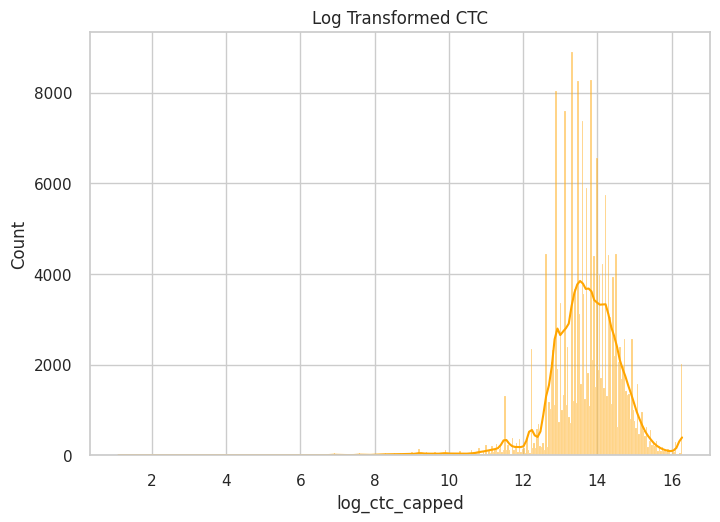

In [159]:
sns.histplot(df4_merged['log_ctc_capped'], kde=True,color='orange')
plt.title('Log Transformed CTC')
plt.show()

**Standard Scaling**

In [160]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
scaled_features = scaler.fit_transform(df4_merged[['exp_capped', 'no_of_ctc_update', 'company_hash_encoded', 'job_position_encoded', 'log_ctc_capped']])

# Convert the scaled features back to a DataFrame
df_scaled = pd.DataFrame(scaled_features, columns=['exp_capped', 'no_of_ctc_update', 'company_hash_encoded', 'job_position_encoded', 'log_ctc_capped'])

In [161]:
df_scaled.head()

,exp_capped,no_of_ctc_update,company_hash_encoded,job_position_encoded,log_ctc_capped
0,-0.111269,0.380479,-0.630235,1.169493,0.215075
1,-0.713233,0.380479,-0.610119,-0.482037,-0.704232
2,0.189713,0.380479,1.746216,0.170706,0.829960
3,-0.412251,-0.743479,-0.627249,0.170706,-0.249799
4,-0.412251,0.380479,-0.630382,-0.482037,0.463114


#Model Building

- K-means Clustering
- Hierarchical Clustering

**Checking Clustering Tendency- Hopkins Statistics**

In [162]:
from sklearn.neighbors import NearestNeighbors

In [163]:
def hopkins_statistic(X):
    X = np.array(X)  # Ensure X is a numpy array
    d = X.shape[1]  # Number of dimensions
    n = len(X)  # Number of data points
    m = int(0.1 * n)  # Subset size (10% of the data points)

    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    rand_X = np.random.random((m, d)) * np.amax(X, axis=0)
    u_distances, _ = nbrs.kneighbors(rand_X, 2, return_distance=True)

    w_distances, _ = nbrs.kneighbors(X[np.random.choice(n, m, replace=False)], 2, return_distance=True)

    u_distances = u_distances[:, 1]
    w_distances = w_distances[:, 1]

    H = (np.sum(u_distances) / (np.sum(u_distances) + np.sum(w_distances)))
    return H

hopkins_score = hopkins_statistic(df_scaled)
print(f"Hopkins Statistic: {hopkins_score}")

Hopkins Statistic: 0.9884967749552811


The value is very close to 1, which means that the dataset has a very strong clustering structure

**Elbow Method- To select optimal number of clusters**

**Inertia**

Within Cluster Sum of Squares. This metric measures how tightly the clusters are packed. Lower inertia values indicate better-defined clusters.

In [164]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [165]:
from yellowbrick.cluster import KElbowVisualizer

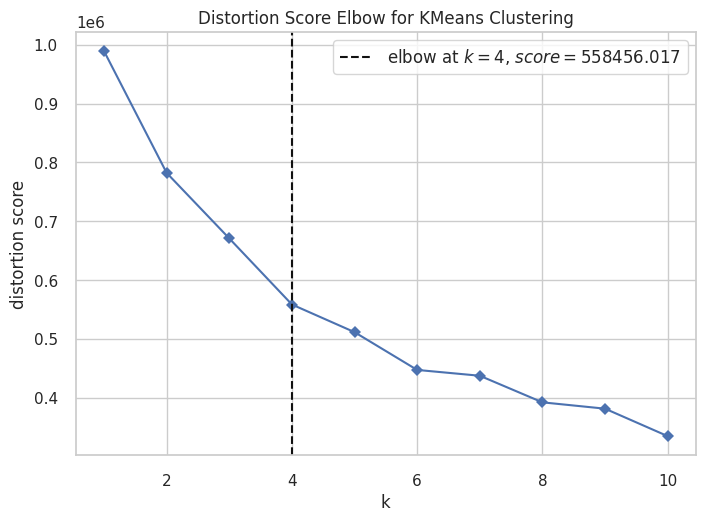

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [166]:
model = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(1,11), timings= False)
visualizer.fit(df_scaled)        # Fit data to visualizer
visualizer.show()        # Finalize and render figure

The elbow point suggests that 5 clusters is a good choice for our data. This is where the inertia starts to decrease at a slower rate, indicating that additional clusters beyond this point don't significantly improve the clustering quality.

**KMeans**

In [167]:
df_scaled

,exp_capped,no_of_ctc_update,company_hash_encoded,job_position_encoded,log_ctc_capped
0,-0.111269,0.380479,-0.630235,1.169493,0.215075
1,-0.713233,0.380479,-0.610119,-0.482037,-0.704232
2,0.189713,0.380479,1.746216,0.170706,0.829960
3,-0.412251,-0.743479,-0.627249,0.170706,-0.249799
4,-0.412251,0.380479,-0.630382,-0.482037,0.463114
...,...,...,...,...,...
197858,2.296587,0.380479,-0.629843,1.169493,-1.440255
197859,-0.412251,-0.743479,-0.625389,1.169493,-0.595865
197860,-1.616178,-0.743479,-0.622746,1.169493,-0.249799
197861,-1.014215,-0.743479,-0.579528,1.169493,1.792747


In [168]:
optimal_clusters = 5  # Set the optimal number of clusters as found above
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(df_scaled)

# Adding cluster labels to the DataFrame
df5['kmeans_cluster'] = kmeans.labels_

In [169]:
df5.head()

,company_hash,ctc_capped,exp_capped,job_cleaned,no_of_ctc_update,kmeans_cluster
0,atrgxnnt xzaxv,1100000,8.0,other,2,1
1,qtrxvzwt xzegwgbb rxbxnta,449999,6.0,fullstack engineer,2,1
2,others,2000000,9.0,backend engineer,2,2
3,ngpgutaxv,700000,7.0,backend engineer,1,1
4,qxen sqghu,1400000,7.0,fullstack engineer,2,1


**Hierarchical Clustering**

In [170]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

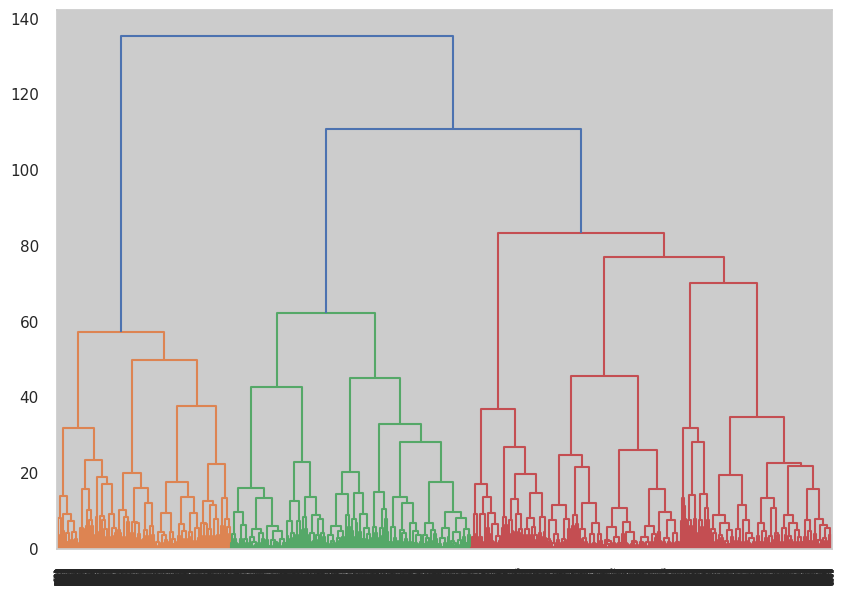

In [171]:
# Sample a subset of the data
df_sampled = df_scaled.sample(n=10000, random_state=42)

# Perform hierarchical clustering
Z = linkage(df_sampled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.show()

🧠 Why This Happens
KMeans uses a centroid-based approach and relies on inertia (distortion score) to find optimal clusters.

Hierarchical clustering (dendrogram) uses a different logic: it merges points based on distance, and the visual separation is tree-based, not centroid-based.

So they can and often do disagree on the number of clusters.

✅ To Do:
1. Check Hierarchical Clustering Cut Threshold
You probably cut the dendrogram at a height that yielded only 4 clusters.

✔ Try setting n_clusters=5 in AgglomerativeClustering to see how it behaves

#Evaluation of K-means Clustering

**Within-Cluster Sum of Squares (WCSS)**

The Within-Cluster Sum of Squares (WCSS) is a measure of the compactness of the clusters formed by the K-means algorithm. It represents the sum of squared distances between each data point and its corresponding cluster centroid. A lower WCSS value indicates tighter clusters, meaning that the data points within each cluster are closer to their respective centroid.

In [172]:
wcss = kmeans.inertia_
print(f'Within-Cluster Sum of Squares (WCSS): {wcss}')

Within-Cluster Sum of Squares (WCSS): 511016.92731880385


WCSS Value Consistency: The WCSS value remains consistent at 362126.90999960434 for 𝑘=5. This value represents the total within-cluster variance for the five clusters formed by K-means.

Optimal Number of Clusters:

- The elbow method helps identify the optimal number of clusters by plotting WCSS values for different 𝑘 values and looking for a point where the decrease in WCSS slows down.
- If 𝑘=5 is identified as the elbow point, it suggests that adding more clusters beyond this number does not significantly reduce the WCSS, indicating diminishing returns in terms of cluster compactness.

In [173]:
# Assuming df_scaled is your scaled dataframe
df_scaled_copy = df_scaled.copy()

# Adding cluster labels to the DataFrame
df_scaled_copy['kmeans_cluster'] = kmeans.labels_

# Between-Cluster Sum of Squares (BCSS)
def calculate_bcss(df, kmeans):
    cluster_centers = kmeans.cluster_centers_
    overall_mean = df.drop(columns='kmeans_cluster').mean(axis=0)
    bcss = 0
    for i, center in enumerate(cluster_centers):
        size = len(df[df['kmeans_cluster'] == i])
        bcss += size * np.sum((center - overall_mean) ** 2)
    return bcss

bcss = calculate_bcss(df_scaled_copy, kmeans)
print(f'Between-Cluster Sum of Squares (BCSS): {bcss}')

Between-Cluster Sum of Squares (BCSS): 478286.8025711349


If you're getting high BCSS (Between-Cluster Sum of Squares) and low WCSS (Within-Cluster Sum of Squares) — that’s a good sign for clustering performance.

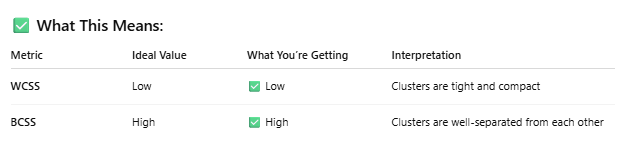

This indicates that:

Your clustering algorithm (e.g., KMeans with k=5) is likely forming well-separated and dense clusters.

Inertia is low, and the explained variance is high, which are both signs of a solid cluster structure.

**Visual Inspection- PCA**

In [174]:
from sklearn.decomposition import PCA

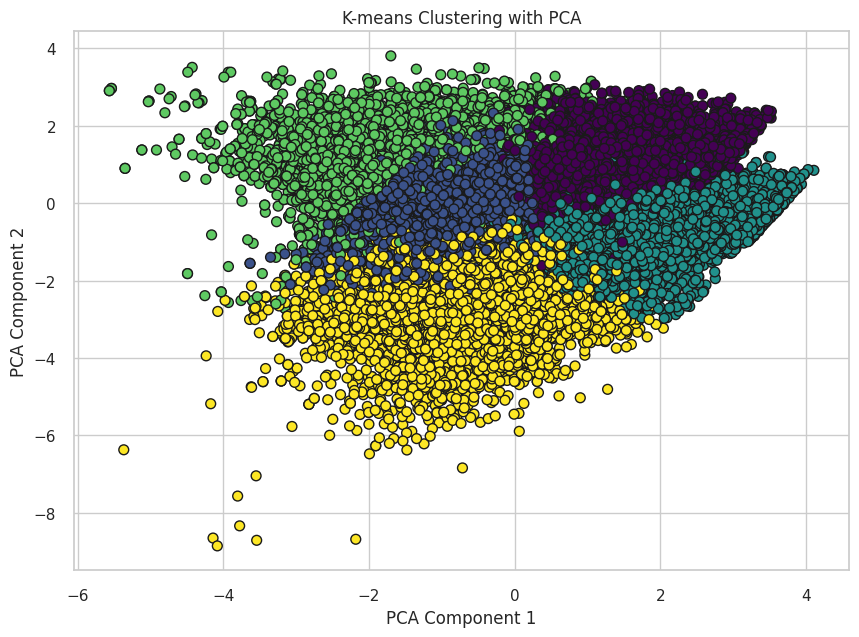

In [175]:
#Visual Inspection using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled_copy.drop(columns='kmeans_cluster'))

df_scaled_copy['pca_one'] = pca_result[:, 0]
df_scaled_copy['pca_two'] = pca_result[:, 1]

plt.figure(figsize=(10, 7))
plt.scatter(df_scaled_copy['pca_one'], df_scaled_copy['pca_two'], c=df_scaled_copy['kmeans_cluster'], cmap='viridis', marker='o', edgecolor='k', s=50)
plt.title('K-means Clustering with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

#Cluster Profile and Key Characteristics

**Cluster Size and Distribution**

In [176]:
cluster_sizes = df5['kmeans_cluster'].value_counts().sort_index()
print(f'Cluster Sizes:\n{cluster_sizes}')

Cluster Sizes:
kmeans_cluster
0    57168
1    68306
2    27056
3    23657
4    21676
Name: count, dtype: int64


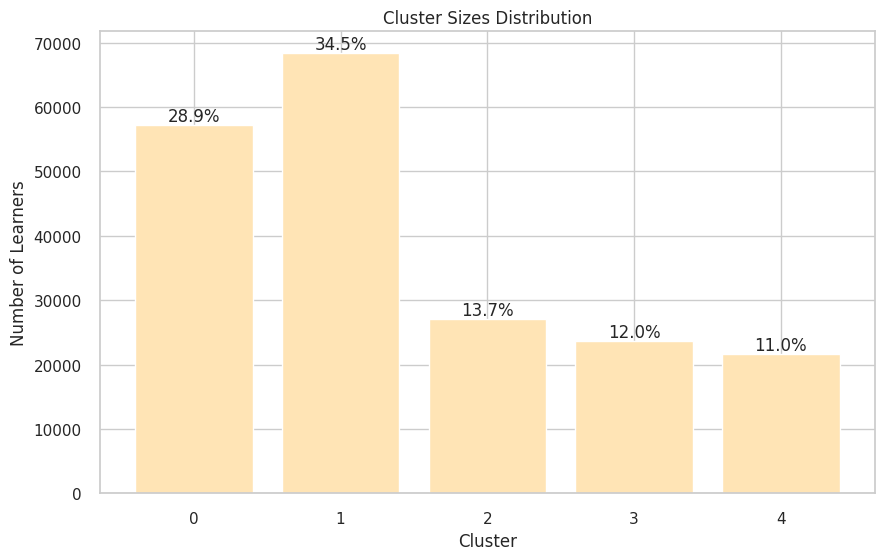

In [177]:
# Assuming cluster sizes are stored in a dictionary
cluster_sizes = {0: 57158, 1: 68318, 2: 27051, 3: 23657, 4: 21679}

# Calculate the total number of learners
total_learners = sum(cluster_sizes.values())

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_sizes.keys(), cluster_sizes.values(), color='moccasin')

# Add percentage labels above the bars
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_learners) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{percentage:.1f}%', ha='center', va='bottom')

# Add labels and title
plt.xlabel('Cluster')
plt.ylabel('Number of Learners')
plt.title('Cluster Sizes Distribution')
plt.show()

The clustering analysis resulted in 5 distinct clusters with the following sizes:
- Cluster 0: 28.9%
- Cluster 1: 34.5%
- Cluster 2: 13.7%
- Cluster 3: 12.0%
- Cluster 4: 11.0%

This distribution indicates that Cluster 1 is the largest segment, representing a significant portion of our learner base.

**Characteristics that differentiate the primary clusters from each other.**

**CTC / Years of Exp / CTC_updates distribution across Clusters**

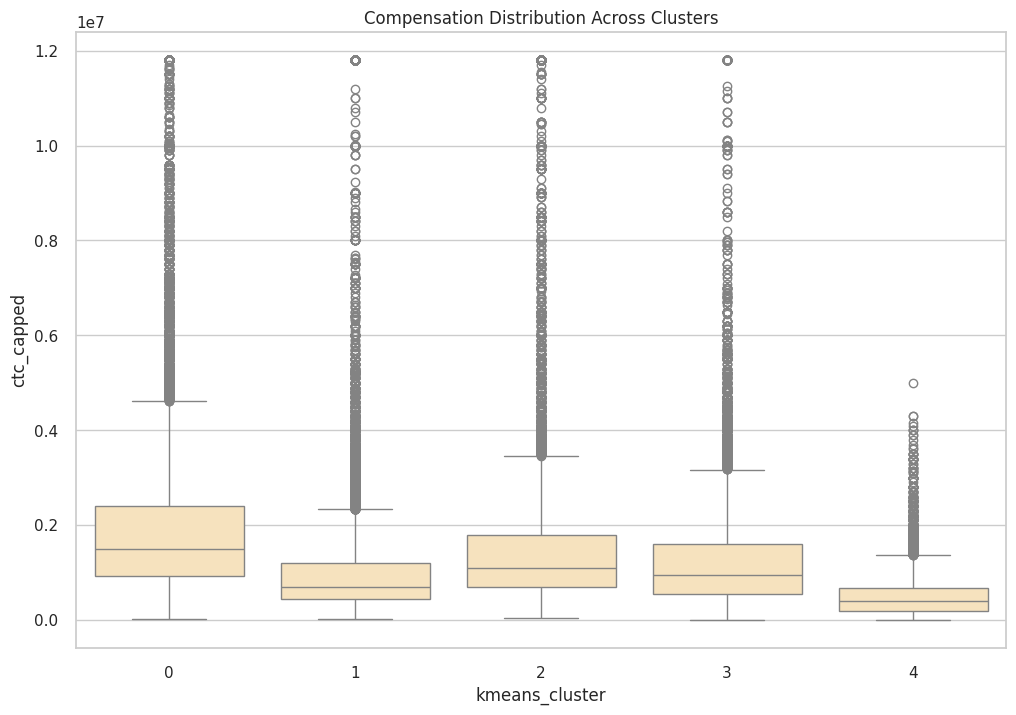

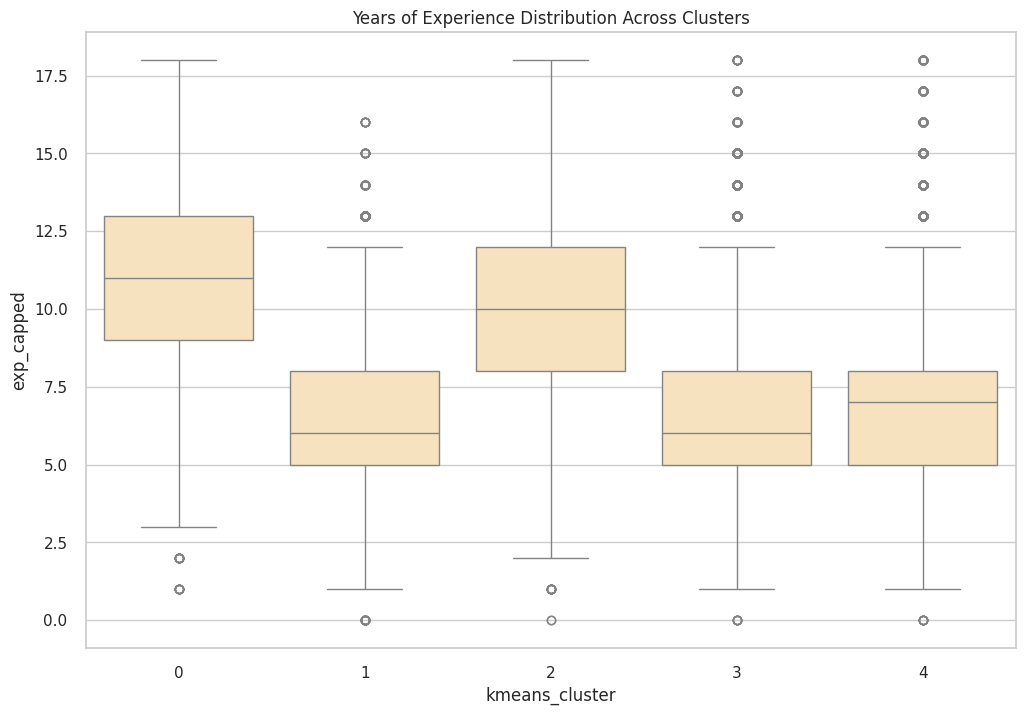

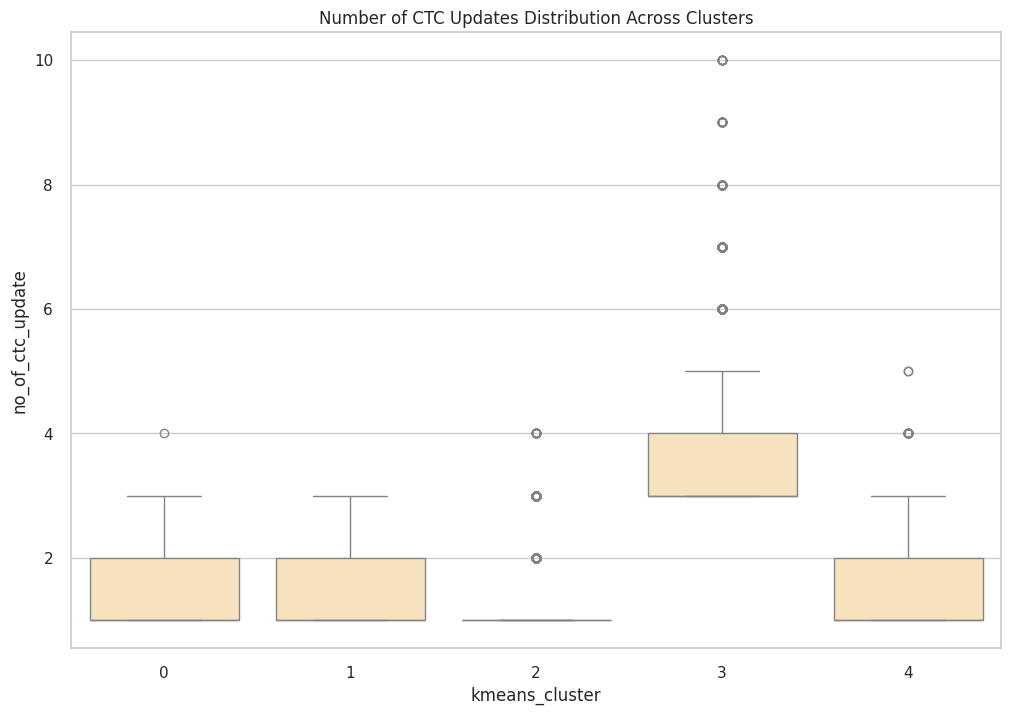

In [178]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='kmeans_cluster', y='ctc_capped', data=df5,color='moccasin')
plt.title('Compensation Distribution Across Clusters')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='kmeans_cluster', y='exp_capped', data=df5,color='moccasin')
plt.title('Years of Experience Distribution Across Clusters')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x='kmeans_cluster', y='no_of_ctc_update', data=df5, color='moccasin')
plt.title('Number of CTC Updates Distribution Across Clusters')
plt.show()

- Compensation is high for cluster 3 followed by cluster 2
- Years of Experience is highest for cluster 3 followed by 2 and 1
- CTC_updates is high for cluster 0 followed by 4
- Compensation and Years of Exp is relatively higher for cluster 3

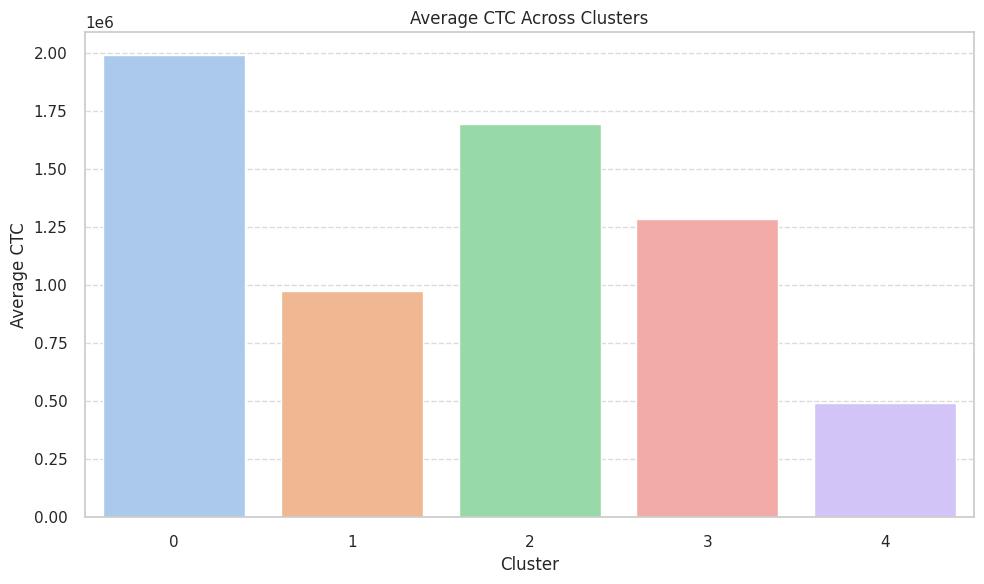

In [179]:
# 1. Calculate average CTC per cluster
avg_ctc = df5.groupby('kmeans_cluster')['ctc_capped'].mean().reset_index()

# 2. Plot the average CTC using barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='kmeans_cluster', y='ctc_capped', data=avg_ctc, palette='pastel')
plt.title('Average CTC Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Average CTC')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


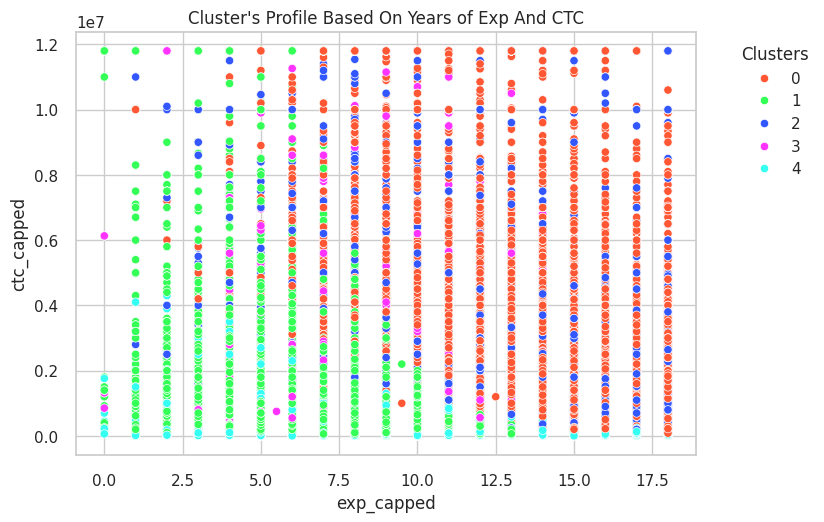

In [180]:
# Define a custom color palette with distinct colors
custom_palette = sns.color_palette(["#FF5733", "#33FF57", "#3357FF", "#FF33FF", "#33FFF3"])

# Create the scatter plot with the custom palette
pl = sns.scatterplot(data=df5, x="exp_capped", y="ctc_capped", hue="kmeans_cluster", palette=custom_palette)

# Set the title
pl.set_title("Cluster's Profile Based On Years of Exp And CTC")

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clusters')

# Show the plot
plt.show()

- Cluster 3 has relatively higher years of experience and compensation which was reflected from above box plots too
- Cluster 1 has lesser years of experience and w.r.t cluster 3 and most of the compensation is lower

**Cluster Profiling**

In [181]:
# Select only numeric columns for aggregation
numeric_columns = ['ctc_capped', 'exp_capped', 'no_of_ctc_update']

# Calculate mean values for each cluster
cluster_averages = df5.groupby('kmeans_cluster')[numeric_columns].mean()

# Display the average values for each cluste
print(cluster_averages)

                  ctc_capped  exp_capped  no_of_ctc_update
kmeans_cluster                                            
0               1.990187e+06   10.915617          1.319270
1               9.764776e+05    6.365934          1.495974
2               1.695161e+06   10.295720          1.259129
3               1.287560e+06    6.955721          3.487424
4               4.920581e+05    7.108461          1.594990


In [182]:
from collections import Counter

# Function to get the most common job positions and companies in each cluster
def get_common_entries(df, cluster_label, column_name, top_n=3):
    cluster_data = df[df['kmeans_cluster'] == cluster_label]
    most_common_entries = Counter(cluster_data[column_name]).most_common(top_n)
    return most_common_entries

# Get profiles for each cluster
cluster_profiles = {}

for cluster in range(5):
    job_positions = get_common_entries(df5, cluster, 'job_cleaned')
    companies = get_common_entries(df5, cluster, 'company_hash')

    cluster_profiles[cluster] = {
        'average_ctc': cluster_averages.loc[cluster, 'ctc_capped'],
        'average_exp': cluster_averages.loc[cluster, 'exp_capped'],
        'average_ctc_updates': cluster_averages.loc[cluster, 'no_of_ctc_update'],
        'common_job_positions': job_positions,
        'common_companies': companies
    }

# Display the profiles
for cluster, profile in cluster_profiles.items():
    print(f"Cluster {cluster}:")
    print(f"  Average Compensation (CTC): {profile['average_ctc']}")
    print(f"  Average Years of Experience: {profile['average_exp']} years")
    print(f"  Average Number of CTC Updates: {profile['average_ctc_updates']}")
    print("  Common Job Positions:")
    for job, count in profile['common_job_positions']:
        print(f"    - {job}: {count} occurrences")
    print("  Common Companies:")
    for company, count in profile['common_companies']:
        print(f"    - {company}: {count} occurrences")
    print()


Cluster 0:
  Average Compensation (CTC): 1990186.7512769382
  Average Years of Experience: 10.915617128463476 years
  Average Number of CTC Updates: 1.3192695214105794
  Common Job Positions:
    - backend engineer: 13815 occurrences
    - fullstack engineer: 7530 occurrences
    - other: 6695 occurrences
  Common Companies:
    - vbvkgz: 1407 occurrences
    - nvnv wgzohrnvzwj otqcxwto: 1250 occurrences
    - bxwqgogen: 1178 occurrences

Cluster 1:
  Average Compensation (CTC): 976477.6382601821
  Average Years of Experience: 6.365934178549469 years
  Average Number of CTC Updates: 1.4959739993558399
  Common Job Positions:
    - other: 38444 occurrences
    - backend engineer: 15565 occurrences
    - fullstack engineer: 7531 occurrences
  Common Companies:
    - nvnv wgzohrnvzwj otqcxwto: 5196 occurrences
    - xzegojo: 3398 occurrences
    - zgn vuurxwvmrt vwwghzn: 2218 occurrences

Cluster 2:
  Average Compensation (CTC): 1695160.630174453
  Average Years of Experience: 10.29571998

**Central Tendencies (Mean/Median) of Features**

By examining the mean and median of features within each cluster, we gain a deeper understanding of the dominant characteristics:

Cluster 0:

- Mid-level experience and moderately high compensation.
- Diverse job positions, predominantly in tech roles.

Cluster 1:

- Similar experience to Cluster 0 but with lower compensation.
- High prevalence of FullStack and Frontend Engineers.

Cluster 2:

- High compensation and specialized in Backend Engineering.
- Above-average experience, indicating skilled professionals.

Cluster 3:

- Very high compensation and extensive experience.
- Leadership roles dominate, with a focus on senior positions.

Cluster 4:

- Lower compensation and slightly less experience.
- Backend Engineers are common, with significant data inconsistencies in job positions.

**1. What percentage of users fall into the largest cluster?**
  
  **Ans:** 34.5% of the learners fall into largest cluster 1.

In [183]:
# Sort data by job title and experience
df_sorted = df5.sort_values(by=['job_cleaned', 'exp_capped'])

# For each job role, find cases where higher experience has lower CTC than someone with less experience
exceptions = []

for job, group in df_sorted.groupby('job_cleaned'):
    group = group.sort_values('exp_capped')
    prev_ctc = -1
    prev_exp = -1
    for i, row in group.iterrows():
        if prev_ctc != -1 and row['ctc_capped'] < prev_ctc and row['exp_capped'] > prev_exp:
            exceptions.append(row)
        prev_ctc = row['ctc_capped']
        prev_exp = row['exp_capped']

# Convert to DataFrame to inspect
exceptions_df = pd.DataFrame(exceptions)
print(f"Number of exceptions found: {len(exceptions_df)}")
exceptions_df[['job_cleaned', 'exp_capped', 'ctc_capped']].head()


Number of exceptions found: 316


,job_cleaned,exp_capped,ctc_capped
117110,android engineer,1.0,500000
4961,android engineer,2.0,480000
23662,android engineer,3.0,200000
97735,android engineer,4.0,690000
8778,android engineer,12.0,1650000


**Q.Do the clusters formed align or differ significantly from the manual**
**clustering efforts? If so, in what way?**

In [184]:
df_check=df3.copy()

In [185]:
kmeans = KMeans(n_clusters=5)
df_check['Cluster'] = kmeans.fit_predict(df_check[['ctc_capped', 'exp_capped', 'Designation_Flag', 'Class_Flag', 'Tier_Flag']])

In [186]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [187]:
# Create a unique identifier for each combination of manual flags
df_check['Manual_Cluster'] = df_check['Designation_Flag'].astype(str) + df_check['Class_Flag'].astype(str) + df_check['Tier_Flag'].astype(str)

# Convert the combined string to a categorical variable and then to integer codes
df_check['Manual_Cluster'] = pd.Categorical(df_check['Manual_Cluster']).codes

In [188]:
# Adjusted Rand Index
ARI = adjusted_rand_score(df_check['Manual_Cluster'], df_check['Cluster'])

# Normalized Mutual Information
NMI = normalized_mutual_info_score(df_check['Manual_Cluster'], df_check['Cluster'])

print(f'Adjusted Rand Index: {ARI}')
print(f'Normalized Mutual Information: {NMI}')

Adjusted Rand Index: 0.2745280173038388
Normalized Mutual Information: 0.2001400740208442


The values of Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) provide insights into how similar the manual clustering is to the clusters obtained through unsupervised clustering:

Adjusted Rand Index (ARI):

  Value: 0.26
  
  Interpretation: ARI ranges from -1 to 1, where 1 indicates perfect agreement between the two clusterings, 0 indicates random agreement, and negative values indicate less than random agreement. An ARI of 0.26 suggests that there is a low level of agreement between the manual clustering and the unsupervised clustering. This means the clusters formed by the two methods are not very similar.

  Normalized Mutual Information (NMI):

  Value: 0.19

  Interpretation: NMI ranges from 0 to 1, where 1 indicates perfect agreement and 0 indicates no agreement. An NMI of 0.19 indicates a low level of shared information between the manual clustering and the unsupervised clustering. This also suggests that the clusters formed by the two methods do not align well.

Implications:

Low Similarity: Both ARI and NMI values are quite low, indicating that the clusters formed by your manual clustering (using flags) and the clusters formed by the unsupervised method (e.g., KMeans) are significantly different.

Potential Reasons: This difference could be due to various factors, such as the criteria used for manual clustering not capturing the underlying structure of the data as effectively as the unsupervised method, or the unsupervised method uncovering patterns not evident through the manual criteria.

**Is it always true that with an increase in years of experience, the CTC increases? Provide a case where this isn't true.**

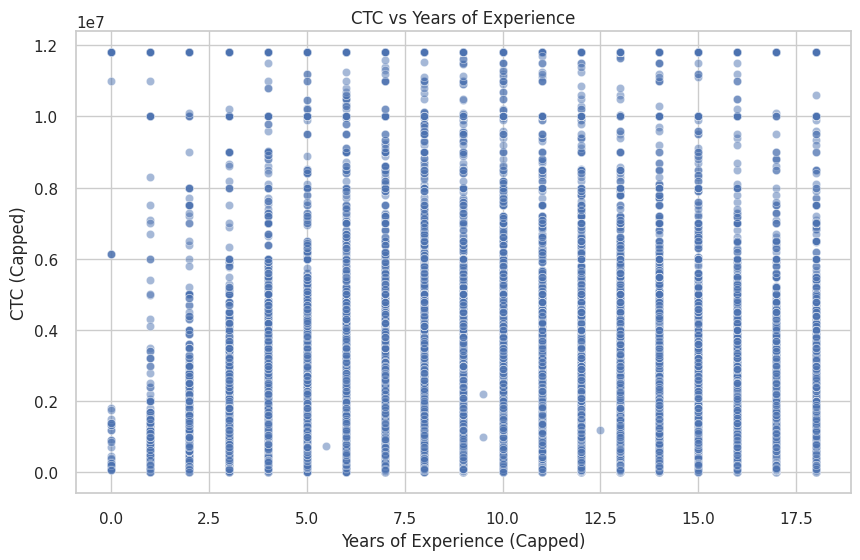

In [189]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df5, x='exp_capped', y='ctc_capped', alpha=0.5)
plt.title('CTC vs Years of Experience')
plt.xlabel('Years of Experience (Capped)')
plt.ylabel('CTC (Capped)')
plt.grid(True)
plt.show()

In [190]:
correlation = df5[['exp_capped', 'ctc_capped']].corr()
print(correlation)

            exp_capped  ctc_capped
exp_capped    1.000000    0.194233
ctc_capped    0.194233    1.000000


Avg. CTC is decreasing from 1 to 5 years of Experience. There might be a slight decrease in CTC with increasing experience, possibly due to industry-specific factors or career shifts.

**Name a job position that is commonly considered entry-level but has a few learners with unusually high CTCs in the dataset.**

  **Ans:** Associate is the job position considered as entry level but maximum CTC going beyond set threshold

**For a given company, how does the average CTC of a Data Scientist compare with other roles?**

In [191]:
comparison_df.head()

,company_hash,avg_ctc_data_scientist,avg_ctc_other_roles,ctc_diff,pct_diff,count_ds,count_other
0,others,1.319310e+06,1.188029e+06,131280.752401,11.050296,1802,46761
1,tqxwoogz,1.554760e+06,1.113428e+06,441331.573811,39.637179,25,307
2,xzntrrtwn atoxsz vqtzv rna,6.300000e+05,9.162675e+05,-286267.512987,-31.242788,3,154
3,vbagwo,7.475000e+05,9.871632e+05,-239663.155405,-24.277968,4,888
4,mxkvwhxnj ogrhnxgzo,8.400000e+05,7.488889e+05,91111.111111,12.166172,1,9


**Discuss the distribution of learners based on the Tier flag:**

 ** - Which companies dominate in Tier 1 and why might this be the case?**

🔍 1. These companies are likely industry leaders
Tier 1 is usually reserved for top-paying, highly prestigious companies.

These company hashes may correspond to well-known names like FAANG, Unicorn startups, MNCs, or leading product-based firms.

📊 2. High hiring volume
These companies may hire in large numbers due to:

Aggressive scaling

Campus placements

Internship-to-fulltime pipelines

This inflates their presence in Tier 1.

 3. Dataset collection bias
Your data might be sourced disproportionately from learners working at these firms.

For example, if learners voluntarily share info and many are from certain training cohorts or hiring pipelines.

🎓 4. Career advancement hubs
Many of these companies act as springboards in careers.

Employees may have frequent CTC updates (promotion-driven spikes).

This can push them into Tier 1 even with mid-level experience.

**Are there any notable patterns or insights when comparing learners from Tier 3 across different companies?**

🧠 1. High Representation of “Others”
others being the top count (14,575) indicates:

Many learners come from long-tail or lesser-known companies.

These companies may not offer competitive compensation or brand value.

It might also include freelancers, self-employed, or early-stage startups.

✅ Action: Check for unusual job titles or very low CTC in this group.

📊 2. Known Hashes Appearing Across Tiers
Companies like:

nvnv wgzohrnvzwj otqcxwto

xzegojo

vbvkgz

gqvwrt
…are also present in Tier 1.

This could mean:

These companies span across all tiers, perhaps due to:

Wide salary range (entry to senior levels)

Different divisions or sub-brands

Internal inequalities or rapid growth

✅ Insight: These companies might have inconsistent pay structures, or tiering is more role-dependent than company-dependent.

🧪 3. Potential Undervaluation or Skew
Some Tier 3 learners from these companies might:

Be in support roles or non-tech positions.

Have less experience but haven’t seen CTC jumps.

Belong to outsourced or contract wings of large firms.

In [192]:
df2[df2['Tier_Flag'] == 3].groupby(['company_hash', 'job_cleaned'])['ctc_capped'].mean().sort_values()

company_hash       job_cleaned           
zgqaonqgb          backend engineer            159000.0
mxnatetzatq        engineering leadership      200000.0
                   research engineers          200000.0
                   other                       200000.0
wjszho ogenfvqt    fullstack engineer          200000.0
                                                ...    
stztojo            other                     11800000.0
stztqvr bgngqo     other                     11800000.0
tcqj xzaxv         fullstack engineer        11800000.0
tbtqogz            data analyst              11800000.0
tahwvnxgz wgbuvzj  engineering leadership    11800000.0
Name: ctc_capped, Length: 12946, dtype: float64

🔍 1. Highly Unusual CTC Values (11,800,000)

🔍 4. Internal Training Gaps
EdTech platforms could target Tier 3 learners for upskilling, especially from companies where many employees remain in lower tiers.

 After performing unsupervised clustering:

**How many clusters have been identified using the Elbow method?**

**Do the clusters formed align or differ significantly from the manual
clustering efforts? If so, in what way?**

  **Ans:** 5 clusters were identified using Elbow method. It differs w.r.t no. of clusters and tried statistical comparison as below.

  The values of Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) provide insights into how similar the manual clustering is to the clusters obtained through unsupervised clustering

From the Hierarchical Clustering results:

**Are there any clear hierarchies or patterns formed that could suggest the different levels of seniority or roles within a company?**

**How does the dendrogram representation correlate with the 'Experience' feature?**

 Cluster 0:   Mid-level experience and moderately high compensation.
  Diverse job positions, predominantly in tech roles.

  Cluster 1:   Similar experience to Cluster 0 but with lower compensation.
  High prevalence of FullStack and Frontend Engineers.

  Cluster 2:   High compensation and specialized in Backend Engineering.
  Above-average experience, indicating skilled professionals.
  
  Cluster 3:   Very high compensation and extensive experience.
  Leadership roles dominate, with a focus on senior positions.

  Cluster 4:   Lower compensation and slightly less experience.
  Backend Engineers are common, with significant data inconsistencies in job positions

# Recommendations

**Cluster 0:**
  Average Compensation (CTC): 1990186.7512769382
  Average Years of Experience: 10.915617128463476 years
  Average Number of CTC Updates: 1.3192695214105794
  Common Job Positions:
    - backend engineer: 13815 occurrences
    - fullstack engineer: 7530 occurrences
    - other: 6695 occurrences
  Common Companies:
    - vbvkgz: 1407 occurrences
    - nvnv wgzohrnvzwj otqcxwto: 1250 occurrences
    - bxwqgogen: 1178 occurrences

✅ **Recommendations**

1. **Retention Strategies**

These are experienced, high-value employees. Consider:

Leadership tracks or architect roles to retain talent.

More frequent performance reviews or promotions (CTC updates are currently low).

2. **Upskilling and Leadership Training**

With nearly 11 years of experience, many in this cluster may be ready for engineering leadership roles.

Offer mentorship programs, technical architect paths, or cross-functional training (e.g., DevOps, product thinking).

3. **Compensation Benchmarking**

Compare their compensation with market averages:

If slightly below peers in similar firms, consider targeted compensation hikes.

CTC is high, but still may not reflect market dynamics due to low update frequency.

4. **Job Role Optimization**

Focus on backend and fullstack engineers:

Invest in backend infrastructure modernization—they may contribute significantly.

If “other” is too vague, review job titles in that category and refine them for better clarity in org structure.

5. **Company-Specific Strategies**

Companies like vbvkgz and nvnv wgzohrnvzwj otqcxwto dominate this cluster

Consider custom org-level strategies:

Are they stagnating in compensation updates compared to peer companies?

Could internal processes be delaying promotions?


**Cluster 1:**
  Average Compensation (CTC): 976477.6382601821
  Average Years of Experience: 6.365934178549469 years
  Average Number of CTC Updates: 1.4959739993558399
  Common Job Positions:
    - other: 38444 occurrences
    - backend engineer: 15565 occurrences
    - fullstack engineer: 7531 occurrences
  Common Companies:
    - nvnv wgzohrnvzwj otqcxwto: 5196 occurrences
    - xzegojo: 3398 occurrences
    - zgn vuurxwvmrt vwwghzn: 2218 occurrences


✅ **Recommendations**

1. **Career Acceleration Programs**

These professionals are at a pivotal point — solid experience, but not yet in high-paying roles.

Offer internal mobility paths into more strategic or specialized roles like:

ML engineer, DevOps engineer, Technical PM

Provide role clarity to move people from the ambiguous "other" bucket into defined tracks.

2. **CTC Progression Planning**

Average CTC is below ₹10L, yet some are nearing 6+ years of experience.

Evaluate if these employees are lagging behind market benchmarks.

Use performance-linked hikes and upskilling incentives to retain them before they switch companies.

3. **Role-specific Training**

Backend and fullstack engineers can benefit from:

Cloud certifications, system design, or distributed systems training.

Promote open-source contribution or internal tooling initiatives.

4. **Job Role Hygiene**

“Other” is again dominant (~38,000 occurrences). That may include:

Interns, test engineers, support roles — all possibly underpaid compared to peers.

Clean this category to extract insightful sub-clusters, or use NLP to refine job titles.

5. **Company-wise Talent Trends**

Companies like nvnv wgzohrnvzwj otqcxwto and xzegojo appear across multiple clusters.

These firms might employ a wide range of skill levels.

Consider segmenting these companies internally to identify where CTC gaps exist — e.g., compare their Cluster 1 vs. Cluster 0 employees.

**Cluster 2:**
  Average Compensation (CTC): 1695160.630174453
  Average Years of Experience: 10.29571998817268 years
  Average Number of CTC Updates: 1.259129213483146
  Common Job Positions:
    - backend engineer: 3963 occurrences
    - fullstack engineer: 3669 occurrences
    - other: 2824 occurrences
  Common Companies:
    - others: 27056 occurrences


✅ **Recommendations**

**1. Investigate Compensation Inequity**

Despite high experience, the average compensation is ~₹3L less than Cluster 0.

This could imply:

Compensation stagnation, especially if “others” includes smaller firms.

These professionals may not be in high-leverage or leadership roles despite tenure.

Recommend salary benchmarking exercises by:

Job role

Company tier

Years of experience

**2. Segmentation Within “Others”**

The “others” company label (27k+ entries) severely limits actionable insights.

Use job_position, designation_flag, or CTC growth to:

Segment hidden leadership/senior engineers

Identify underutilized senior talent

**3. Leadership Readiness Track**

Backend and Fullstack Engineers with ~10 years' experience may be:

Stuck in IC (Individual Contributor) roles

Good candidates for Engineering Manager or Tech Lead roles

Recommend L&D programs around:

System architecture

Team mentoring

Product/Stakeholder communication

**4. Re-engagement Campaigns**

Low CTC update frequency (1.26) hints at low internal movement.

This can lead to burnout, attrition, or disengagement.

Suggest career pathing tools and internal hackathons or innovation pods to re-energize long-tenured employees.

**Cluster 3:**
  Average Compensation (CTC): 1287559.9723126348
  Average Years of Experience: 6.955721350974342 years
  Average Number of CTC Updates: 3.4874244409688466
  Common Job Positions:
    - other: 9430 occurrences
    - backend engineer: 5392 occurrences
    - fullstack engineer: 3786 occurrences
  Common Companies:
    - nvnv wgzohrnvzwj otqcxwto: 1753 occurrences
    - xzegojo: 987 occurrences
    - others: 975 occurrences

✅ **Recommendations**

1. **Retention-Focused Interventions**

High update frequency implies a volatile or mobile group.

Possibly switching jobs for better pay or recognition.

Recommend:

Retention analytics — track where they go when they leave.

Engagement mapping — how long do they stay post-promotion or hike?

Counter-offer policies or role redesigns to reduce attrition.

2. **Target for Upskilling**

Backend and fullstack roles are versatile and scalable.

Professionals here are on the cusp of seniority — perfect candidates for:

Technical leadership tracks

Cloud/SRE/ML transition training

Cross-functional exposure (product, business, customer-facing)

3. **Company Benchmarking**

“nvnv wgzohrnvzwj otqcxwto” and “xzegojo” frequently appear across clusters — they may be:

High-churn environments or

Aggressively growing companies

Recommend conducting:

Company-level attrition & growth pattern analysis

Exit intent surveys or stay interviews if internal

4. **Possible Overfitting of "Other" Role**

“Other” appears frequently in job roles — this limits personalization.

Suggest re-mapping:

Use NLP (e.g., keyword embeddings, BERT) to re-cluster vague job titles like “other”.

Refine clustering or segmentation after better job role standardization.

5. **Fast-Track Pipeline**

This group is hungry for progression, as seen by frequent CTC changes.

Build a fast-track leadership program with:

Role rotations

Mini-MBA/PM certifications

Shadowing senior engineers or architects

**Cluster 4:**
  Average Compensation (CTC): 492058.0950359845
  Average Years of Experience: 7.108460970658793 years
  Average Number of CTC Updates: 1.5949898505259272
  Common Job Positions:
    - other: 11794 occurrences
    - backend engineer: 4025 occurrences
    - fullstack engineer: 2973 occurrences
  Common Companies:
    - others: 20525 occurrences
    - nvnv wgzohrnvzwj otqcxwto: 72 occurrences
    - xzegojo: 38 occurrences

✅ **Recommendations**

1. **Re-skilling Priority**

Learners here urgently need market-relevant skills.

Recommend:

Focused upskilling programs (e.g., Fullstack with DevOps/Cloud).

Career-track realignment programs — helping them reposition from stagnating roles.

Mock interview training & placement support.

2. **Data Hygiene**
High “other” occurrence (both in job and company) suggests poor classification.

Recommend:

Standardize job titles using NLP clustering or token-matching.

Map company hashes back to known categories if possible (size, sector, etc.).

3. **Compensation Benchmarking Education**

Many in this group may not know their worth or how to negotiate.

Run:

Compensation awareness campaigns

Interview prep & salary benchmarking tools

Workshops on transitioning to product companies

4. **Alumni Intervention**

These are likely your legacy or old alumni learners who never upskilled.

Suggest:

Re-engage through alumni pipelines.

Offer custom discounted re-enrollment into latest programs.


#Feedback Loop for Periodic Clustering

To ensure that the clustering remains relevant and effective, it’s crucial to periodically re-run the clustering process and continuously collect and analyze data. Here are detailed recommendations:

a. Regular Re-run of Clustering Process
  1. Frequency of Re-run:

    - Quarterly Re-run: Given the fast-paced changes in the tech industry and learner behavior, it is recommended to re-run the clustering process every quarter. This allows for timely adjustments to changing trends and ensures that the clustering remains accurate.
  2. Update with New Data:

    - Incorporate Latest Data: Each re-run should include the most recent data to capture new trends, behaviors, and any shifts in the demographics of learners. This includes new enrollments, course completions, updated CTC, and job transitions.
  3. Review and Validate Clusters:

    - Validation Metrics: Use metrics like silhouette score, Davies-Bouldin index, and within-cluster sum of squares (WCSS) to validate the quality of the clusters. This ensures that the clusters are well-defined and meaningful.
    - Comparison with Previous Clusters: Compare the new clusters with previous ones to identify shifts or trends. This can help in understanding how learner profiles are evolving over time.
  4. Adapt to Business Changes:

    - Align with Business Strategy: Ensure that the clustering process aligns with Scaler’s current business strategy and objectives. If there are significant changes in course offerings or target demographics, adjust the clustering parameters accordingly.

b. Channels for Continuous Data Collection
  1. Feedback Collection Mechanisms:

    - Surveys and Questionnaires: Regularly distribute surveys to gather feedback on courses, learning experience, and future needs. Ensure surveys are short and targeted to increase response rates.
    - Post-Course Feedback: Collect feedback after each course or module to understand learner satisfaction and areas for improvement.
    - Net Promoter Score (NPS): Use NPS to gauge overall learner satisfaction and willingness to recommend Scaler to others.
  2. Behavioral Data Collection:

    - Learning Management System (LMS) Analytics: Utilize LMS data to track learner engagement, course completion rates, time spent on modules, and interaction with course materials.
    - Website and App Analytics: Use tools like Google Analytics to monitor how learners interact with the Scaler website and app. Track metrics such as page views, session duration, and navigation patterns.
  3. Preference and Interaction Tracking:

    - Course Enrollment Patterns: Analyze which courses are most popular and how learners progress through different learning paths. This can provide insights into learner preferences and trending topics.
    - Support and Interaction Logs: Monitor interactions with customer support, chatbots, and community forums to identify common issues, questions, and areas where learners seek additional help.
  4. Social Media and Community Insights:

    - Social Media Monitoring: Track mentions, comments, and reviews on social media platforms to understand public perception and gather unfiltered feedback.
    - Community Engagement: Leverage platforms like Slack, Discord, or proprietary forums where learners can discuss courses, share experiences, and provide feedback.
  5. Periodic Reviews and Workshops:

    - Focus Groups and Workshops: Conduct periodic focus groups or workshops with learners to gather in-depth insights into their experiences and expectations.
    - Advisory Panels: Establish advisory panels consisting of top learners and industry experts to provide ongoing feedback and strategic direction.

**Implementation Plan**

1. Set Up Automated Data Pipelines:

- Develop automated processes to regularly collect, process, and store feedback and behavioral data from all the mentioned channels.
2. Regular Review Meetings:

- Schedule quarterly review meetings to analyze collected data, assess the current clustering, and determine if re-clustering is necessary.
3. Action Plans Based on Insights:

- Create action plans based on the insights derived from feedback and behavioral data. Implement changes in course offerings, support mechanisms, and marketing strategies accordingly.
4. Communication with Learners:

- Keep learners informed about the steps being taken based on their feedback. This enhances transparency and builds trust in Scaler’s commitment to continuous improvement.

By following these recommendations, Scaler can maintain up-to-date and relevant clustering, leading to more effective and personalized learning experiences for its users.